# Chapter 5: Deep Learning on Sequence Data

## Instructor: Rahul Bhadani

In [ ]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
# At the top of your notebook, add:
np.set_printoptions(suppress=True, precision=8)
torch.set_printoptions(sci_mode=False, precision=8)

import torch.nn.functional as F
from PIL import Image

# 1. Example of Filters

In [ ]:
edge_filter = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Sobel - Horizontal
sobel_x = torch.tensor([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=torch.float32)

# Sobel - Vertical
sobel_y = torch.tensor([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]], dtype=torch.float32)

# Prewitt - Horizontal
prewitt_x = torch.tensor([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=torch.float32)

# Prewitt - Vertical
prewitt_y = torch.tensor([[1, 1, 1],
                        [0, 0, 0],
                        [-1, -1, -1]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Diagonal
roberts_x = torch.tensor([[0, 0, 0],
                        [0, 1, -1],
                        [0, 0, 0]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Anti-diagonal
roberts_y = torch.tensor([[0, 0, 0],
                        [0, 1, 0],
                        [0, -1, 0]], dtype=torch.float32)

# Laplacian - 4-connectivity
laplacian_4 = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Laplacian - 8-connectivity
laplacian_8 = torch.tensor([[1, 1, 1],
                            [1, -8, 1],
                            [1, 1, 1]], dtype=torch.float32)

# Kirsch - North
kirsch_n = torch.tensor([[-3, -3, -3],
                        [-3, 0, -3],
                        [5, 5, 5]], dtype=torch.float32)

# Kirsch - East
kirsch_e = torch.tensor([[-3, -3, 5],
                        [-3, 0, 5],
                        [-3, -3, 5]], dtype=torch.float32)

# Robinson - North
robinson_n = torch.tensor([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=torch.float32)

# Frei-Chen
frei_chen = torch.tensor([[1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))],
                        [1, 0, -1],
                        [1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))]], dtype=torch.float32)

sobel_filter = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float32)

## Read an image

In [ ]:
img = Image.open('rose.png').convert('RGB')
img

In [ ]:
torch.from_numpy(np.array(img)).shape

We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches

In [ ]:
img_tensor = torch.from_numpy(np.array(img)).float() / 255.0

# We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

img_tensor.shape

In [ ]:
# Reshape filter: (1, 1, 3, 3) for conv2d
kernel = edge_filter.unsqueeze(0).unsqueeze(0)
kernel.shape

In [ ]:
# Apply filter to each channel
result_channels = []
for i in range(3):  # RGB
    
    # extracts single 4D Tensor Corresponding to each channel
    channel = img_tensor[:, i:i+1, :, :]
    
    # apply convolution 
    filtered = F.conv2d(channel, kernel, padding=1)
    result_channels.append(filtered)

In [ ]:
# Combine channels
filtered_img = torch.cat(result_channels, dim=1)

In [ ]:
# Convert back to numpy for saving/display
output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()

In [ ]:
# Save or display
import matplotlib.pyplot as plt
plt.imshow(np.abs(output), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
def apply_filter(img, filter):
    """
    Apply Filter to image

    Args:
        img (4 D Tensor): Input Image
        filter (4 D Tensor):  Input Filter
    """
    img_tensor = torch.from_numpy(np.array(img)).float() / 255.0
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)
    kernel = filter.unsqueeze(0).unsqueeze(0)
    
    # Apply filter to each channel
    result_channels = []
    for i in range(3):  # RGB
        
        # extracts single 4D Tensor Corresponding to each channel
        channel = img_tensor[:, i:i+1, :, :]
        
        # apply convolution 
        filtered = F.conv2d(channel, kernel, padding=1)
        result_channels.append(filtered)
        
    # Combine channels
    filtered_img = torch.cat(result_channels, dim=1)
    
    # Convert back to numpy for saving/display
    output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()
    
    # Normalize to [0, 1] range
    # because some filters produce values outside range 0 and 1
    #output = (output - output.min()) / (output.max() - output.min())
    
    # Save or display
    import matplotlib.pyplot as plt
    plt.imshow(output, cmap='gray')
    plt.axis('off')
    plt.show()

In [ ]:
filters = [edge_filter, sobel_x, sobel_y,  prewitt_x, prewitt_y, roberts_x, roberts_y,laplacian_4, laplacian_8, kirsch_e, kirsch_n, frei_chen, sobel_filter]
for f in filters:
    apply_filter(img=img, filter=f)

# 2. Understanding Convolution Layer in PyTorch

`conv2d` in PyTorch

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

It performs the following operation:

$$
(f*k)(i, j) = \sum_m \sum_n f(i+m, j + n) \cdot k(m, n)
$$

**Note:** The kernel is flipped in true mathematical convolution, but PyTorch does not flip the kernel – it performs cross‑correlation. This does not affect the network’s ability to learn because the kernels are learned from scratch.

In [ ]:
import torch
import torch.nn as nn

# Create a Conv2d layer
conv = nn.Conv2d(in_channels=1,    # grayscale image
                    out_channels=4,   # number of filters
                    kernel_size=3,    # 3x3 kernel
                    stride=1,
                    padding=0)

# Random input: batch size 2, 1 channel, 5x6 image
x = torch.randn(2, 1, 5, 6)
print(f"x ={x}")
print("Input shape:  ", x.shape)


print(f"Convolution Weight: {conv.weight}")

print(f"Convolution Bias: {conv.bias}")

print(f"Convolution Weight Shape: {conv.weight.shape}")

# Forward pass
out = conv(x)
print("Output shape: ", out.shape)

In [ ]:
5 - 3 + 1,6 - 3 + 1

We used 4 filters

Batch size stays 2

Hence: Output shape:  torch.Size([2, 4, 3, 4]) = batch_size  x filters x height x width

## Padding

Adding padding allows the convolution to be applied to border pixels and can keep the spatial size unchanged.

In [ ]:
conv_pad = nn.Conv2d(1, 3, kernel_size=3, stride=1, padding=1)
out = conv_pad(x)
print("With padding=1:", out.shape)

## Stride
Stride > 1 down‑samples the feature map.

In [ ]:
conv_stride2 = nn.Conv2d(1, 3, kernel_size=3, stride=2, padding=1)
out = conv_stride2(x)
print("Stride=2, padding=1:", out.shape)

⌊(5+2−3)/2+1⌋=⌊4/2+1⌋=3.

## Learnable Parameters

Weight Tensor has shape :  no. of output channel x (input channel/groups) x kernesize[0] x kernelsize[1]

Bias Tensor is 1D Tensor of size of output channel

From documentation (https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): 

`groups` controls the connections between inputs and outputs. `in_channels` and `out_channels` must both be divisible by groups. For example,

At `groups=1`, all inputs are convolved to all outputs.

At `groups=2`, the operation becomes equivalent to having two conv layers side by side, each seeing half the input channels and producing half the output channels, and both subsequently concatenated.

At `groups= in_channels`, each input channel is convolved with its own set of filters (of size `out_channels`/`in_channels`)



## Your own Conv2D

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(Conv2d, self).__init__()
        
        # Store hyperparameters
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)
        
        # Initialize learnable parameters
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, *self.kernel_size))
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.register_parameter('bias', None)
        
        # Initialize weights properly
        self.reset_parameters()
    
    def reset_parameters(self):
        # Kaiming initialization
        nn.init.kaiming_uniform_(self.weight, a=torch.nn.init.calculate_gain('relu'))
        if self.bias is not None:
            nn.init.zeros_(self.bias)
    
    def forward(self, x):
        # Use PyTorch's built-in conv2d function
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding)

# Usage example
conv = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
x = torch.randn(1, 3, 32, 32)  # batch_size=1, channels=3, height=32, width=32
output = conv(x)
print(output.shape)  # torch.Size([1, 16, 32, 32])

# 2. Building an image classifier using Convolutional Network

In [ ]:
!wget https://github.com/rahulbhadani/CPE487587_SP26/releases/download/catsdogs/CatsDogs.zip 
!unzip CatsDogs.zip -d ../Data

In [ ]:
!ls -lrt ../Data/CatsDogs/PetImages

In [ ]:
# Define the CNN architecture
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
         # First convolutional layer: 3 input channels (RGB images), 16 output channels (filters), 3x3 kernel, and padding of 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Second convolutional layer: 16 input channels, 32 output channels, 3x3 kernel, and padding of 1
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Max-pooling layer: 2x2 kernel and stride of 2 (reduces spatial dimensions by half)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # First fully connected layer: 32*32*32 input features (flattened), 128 output features
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        # Final fully connected layer: 128 input features, 2 output features (cat or dog)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: cat and dog

    def forward(self, x):
         # Apply conv1, ReLU activation, and max-pooling
        x = self.pool(torch.relu(self.conv1(x)))
        # Apply conv2, ReLU activation, and max-pooling
        x = self.pool(torch.relu(self.conv2(x)))
         # Flatten the output tensor to a 1D vector
        x = x.view(-1, 32 * 32 * 32)
       # Pass through fc1 with ReLU activation
        x = torch.relu(self.fc1(x))
        # Compute output logits using fc2
        x = self.fc2(x)
        return x

In [ ]:
# Load and preprocess data
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize pixel values
])

In [ ]:
from torch.utils.data import DataLoader, Dataset

In [ ]:
# Define the CatDogDataset class
import os
class CatDogDataset(Dataset):
    def __init__(self, root_folder, transform=None):
        """
        Args:
            root_folder (str): Path to the root folder containing cat and dog images.
            transform (callable, optional): Optional transform to apply to the images.
        """
        # Set the root folder path
        self.root = root_folder
        # Store the image transformation function (if provided)
        self.transform = transform
        # Define the classes (assuming subfolders are named "cat" and "dog")
        #self.classes = ["Cat_Small", "Dog_Small"]
        self.classes = ["Cat", "Dog"]
        # Initialize an empty list to store image filenames
        self.elements = []

        # Collect image filenames
        for class_name in self.classes:
            # Create the full path to the class-specific folder
            class_folder = os.path.join(self.root, class_name)
            # Iterate through files in the class folder
            for filename in os.listdir(class_folder):
                # Check if the file has a ".jpg" extension
                if filename.endswith(".jpg"):
                    # Append the full path of the image file to the list
                    self.elements.append(os.path.join(class_name, filename))

    def __len__(self):
        # Return the total number of images in the dataset
        return len(self.elements)

    def __getitem__(self, index):
        # Open the image using PIL (Pillow)
        img = Image.open(os.path.join(self.root, self.elements[index].rstrip()))
        # Convert the image to RGB format (if it was grayscale)
        img = img.convert("RGB")
        # Determine the target label (index of the class in self.classes)
        target = self.classes.index(self.elements[index].rstrip().split('/')[0])
        # Return the image and its corresponding label
        image, label = img, target

        # Apply the specified transformation (if provided)
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [ ]:
# Create training and test datasets
root_folder = '../Data/CatsDogs/PetImages'
dataset = CatDogDataset(root_folder, transform=transform)

In [ ]:
# Visualize a random sample
import numpy as np
random_idx = np.random.randint(len(dataset))
sample_img, sample_label = dataset[random_idx]

# Convert the PyTorch tensor to a NumPy array
sample_img_np = sample_img.numpy().transpose(1, 2, 0)  # Channels last

# Display the image
plt.imshow(sample_img_np)
plt.title(f"Sample Label: {'Cat' if sample_label == 0 else 'Dog'}")
plt.axis('off')
plt.show()

In [ ]:
# Split the dataset into train and test sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

from torch.utils.data import DataLoader, random_split
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

In [ ]:
# Initialize the model and optimizer
model = CatDogCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [ ]:
num_epochs = 300
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize lists to store loss values and epochs
loss_values = []
epochs = range(1, num_epochs + 1)

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Clear gradients before computing new ones
        outputs = model(images)  #images, labels = images.to(device), labels.to(device) Forward pass: compute model predictions
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backpropagation: compute gradients
        optimizer.step()  # Update model parameters using gradients

    # Append the loss value for this epoch
    loss_values.append(loss.item())
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")


# Create a plot for loss vs. epoch
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epoch')
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the model on the test set
test_loader = DataLoader(test_dataset, batch_size=batch_size)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

In [ ]:
device

In [ ]:
# Load the input image
input_image_path = '../Data/CatsDogs/PetImages/Dog/10001.jpg'
input_image = Image.open(input_image_path)
input_image

In [ ]:
input_tensor = transform(input_image).unsqueeze(0)  # Add batch dimension

input_tensor = input_tensor.to(device)
# Make predictions
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted_class = torch.max(outputs, 1)

# Map class index to label (0 for cat, 1 for dog)
class_labels = ['Cat', 'Dog']
predicted_label = class_labels[predicted_class.item()]

print(f"Predicted label: {predicted_label}")

# 3. Recurrent Neural Network

## RNN Cell: Recurrent Connection

In [ ]:
import torch
import torch.nn as nn

class RNNCell(nn.Module):
    """
    Single RNN Cell implementing: h_t = tanh(xW + h_{t-1}U + b)
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(RNNCell, self).__init__()
        self.hidden_size = hidden_size

        # Input-to-hidden layer
        self.W = nn.Linear(input_size, hidden_size)
        # Hidden-to-hidden layer
        self.U = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x: torch.Tensor, h_prev: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x:      (batch_size, input_size)  — current input
            h_prev: (batch_size, hidden_size) — previous hidden state
        Returns:
            h_t:    (batch_size, hidden_size) — new hidden state
        """
        return torch.tanh(self.W(x) + self.U(h_prev))

In [ ]:
import torch
import torch.nn as nn

input_size  = 5
hidden_size = 8
seq_len     = 5
batch_size  = 1

cell = RNNCell(input_size, hidden_size)

# Simulate a sequence: (seq_len, batch, input_size)
x = torch.randn(seq_len, batch_size, input_size)

# Initial hidden state
h_t = torch.zeros(batch_size, hidden_size)

print("Stepping through time:\n")
for t in range(seq_len):
    print(f"Shape of Input = {x[t].shape}")
    h_t = cell(x[t], h_t)   # feed one step at a time
    print(f"  t={t} | input: {x[t].shape} | h_t: {h_t.shape} | h_t norm: {h_t.norm().item():.4f}")

print(f"\nFinal hidden state:\n{h_t}")

In [ ]:
cell = nn.RNNCell(input_size=5, hidden_size=8)

x   = torch.randn(6, 1, 5)   # 6 time steps
h_t = torch.zeros(1, 8)

history = []  # store all hidden states

for t in range(6):
    h_t = cell(x[t], h_t)
    history.append(h_t.detach().clone())

# Stack into (seq_len, batch, hidden)
all_hidden = torch.stack(history, dim=0)
print(f"All hidden states shape: {all_hidden.shape}")  # (6, 1, 8)

# Visualize how each hidden unit evolves over time
import matplotlib.pyplot as plt

values = all_hidden[:, 0, :].numpy()  # (6, 8)

plt.figure(figsize=(10, 4))
for unit in range(8):
    plt.plot(values[:, unit], marker='o', label=f'h[{unit}]')

plt.title("Hidden Unit Activations Over Time")
plt.xlabel("Time Step")
plt.ylabel("Activation (tanh)")
plt.legend(loc='upper right', ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
cell = nn.RNNCell(input_size=5, hidden_size=8)

# Start with a strong hidden state, then feed zero inputs
h_t        = torch.ones(1, 8)                    # kick it with a strong state
zero_input = torch.zeros(1, 5)                   # no new information

# no new information so hidden state convergence
print("Decay with zero input:\n")
print(f"  init  | h_t norm: {h_t.norm().item():.4f} | values: {h_t.detach().numpy().round(3)}")

for t in range(30):
    h_t = cell(zero_input, h_t)
    print(f"  t={t}   | h_t norm: {h_t.norm().item():.4f} | values: {h_t.detach().numpy().round(3)}")


## Recurrent Neural Network

In [ ]:
class RNN(nn.Module):
    """
    Processes a sequence by unrolling an RNNCell over each time step.
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size)

    def forward(self, x: torch.Tensor, h_0: torch.Tensor = None):
        """
        Args:
            x:   (batch_size, seq_len, input_size) — input sequence
            h_0: (batch_size, hidden_size)         — initial hidden state (optional)
        Returns:
            outputs: (batch_size, seq_len, hidden_size) — all hidden states
            h_n:     (batch_size, hidden_size)          — final hidden state
        """
        batch_size, seq_len, _ = x.size()

        # Initialize hidden state to zeros if not provided
        if h_0 is None:
            h_0 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        h_t = h_0
        outputs = []

        for t in range(seq_len):
            h_t = self.cell(x[:, t, :], h_t)  # step through each time step
            outputs.append(h_t.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch, seq_len, hidden_size)
        return outputs, h_t

In [ ]:
# Hyperparameters
batch_size  = 32
seq_len     = 10
input_size  = 8
hidden_size = 16
output_size = 4

# Model
model     = RNN(input_size, hidden_size)
fc_out    = nn.Linear(hidden_size, output_size)
optimizer = torch.optim.Adam(list(model.parameters()) + list(fc_out.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Dummy forward pass
x      = torch.randn(batch_size, seq_len, input_size)
labels = torch.randint(0, output_size, (batch_size,))


loss_history     = []
accuracy_history = []

num_epochs  = 20000


for epoch in range(num_epochs):
    model.train()

    outputs, h_n = model(x)
    logits       = fc_out(h_n)
    loss         = criterion(logits, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accuracy
    preds    = logits.argmax(dim=1)
    accuracy = (preds == labels).float().mean().item() * 100

    loss_history.append(loss.item())
    accuracy_history.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:>3}/{num_epochs}]  Loss: {loss.item():.4f}  Accuracy: {accuracy:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tomato')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True)

ax2.plot(accuracy_history, color='steelblue')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True)

plt.suptitle("RNN Convergence on Fixed Batch", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Reading Hugging Facedownloaded Data Locally

To read the ImageNet-1k dataset from cached Arrow files, use the Hugging Face `datasets` library with the `load_dataset()` function, specifying the `cache_dir` parameter to point to the parent directory containing the `ILSVRC___imagenet-1k` folder (e.g., `cache_dir="/data/CPE_487-587/imagenet-1k"`). This allows you to access the pre-downloaded dataset without re-downloading, where each split (train, validation, test) can be accessed as `dataset['train']`, `dataset['validation']`, or `dataset['test']`. Each example contains an `'image'` field (a PIL Image object) and a `'label'` field (an integer from 0-999 representing one of 1000 classes). The labels are based on WordNet synsets, meaning each label string contains multiple comma-separated synonyms for the same concept (e.g., "plane, carpenter's plane, woodworking plane"), which includes common names, alternative names, and sometimes scientific names. For practical use, you can extract the primary class name by taking the first word before the comma using `class_names[label_id].split(',')[0]`, where `class_names` is obtained from `train_dataset.features['label'].names`.

In [1]:
!uv add datasets

Resolved 194 packages in 17ms
Audited 135 packages in 28ms


In [2]:
from datasets import config

# Show current cache directory
print(config.HF_DATASETS_CACHE)

/home/rkb0022/.cache/huggingface/datasets


In [3]:
from datasets import load_dataset
import matplotlib.pyplot as plt

# Option A: Set cache_dir parameter
dataset = load_dataset(
    "ILSVRC/imagenet-1k",
    cache_dir="/data/CPE_487-587/imagenet-1k"
)

train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/267 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1281167
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
})

In [5]:
train_dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 1281167
})

In [6]:
val_dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 50000
})

In [7]:
test_dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 100000
})

In [8]:
first_example = train_dataset[0]

# Extract image and label
image = first_example['image']  # PIL Image
label = first_example['label']  # Integer class ID

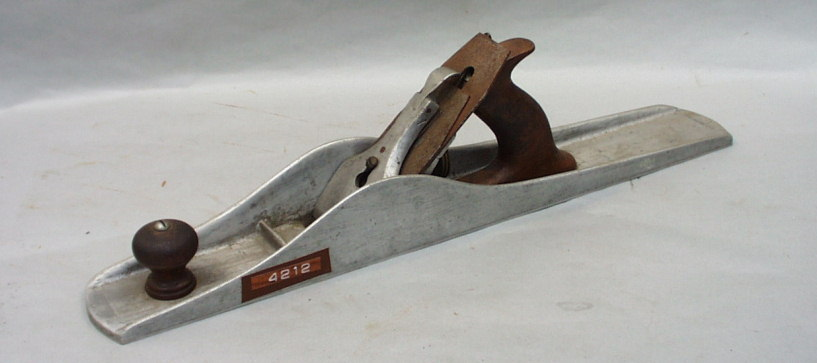

In [9]:
image

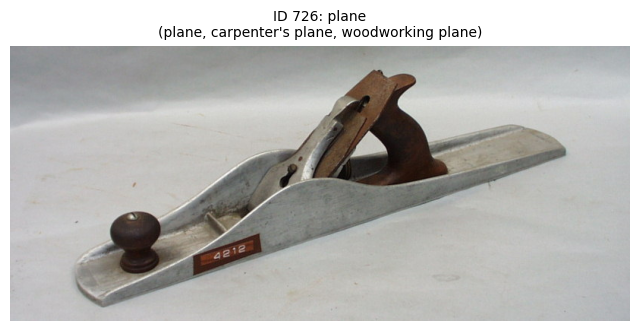

In [12]:
import matplotlib.pyplot as plt

class_names = train_dataset.features['label'].names
class_name = class_names[label]
class_name

first_example = train_dataset[0]
image = first_example['image']
label_id = first_example['label']

full_label = class_names[label_id]
primary_name = full_label.split(',')[0].strip()

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(f"ID {label_id}: {primary_name}\n({full_label})", fontsize=10)
plt.axis('off')
plt.show()

In [13]:
label

726

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/267 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

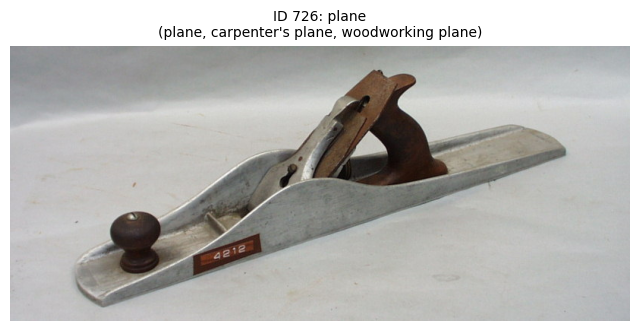

Number of classes: 1000


In [14]:
from datasets import load_dataset
import matplotlib.pyplot as plt

# Option A: Set cache_dir parameter
dataset = load_dataset(
    "ILSVRC/imagenet-1k",
    cache_dir="/data/CPE_487-587/imagenet-1k"
)

train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

import matplotlib.pyplot as plt

first_example = train_dataset[0]
image = first_example['image']
label_id = first_example['label']

full_label = class_names[label_id]
primary_name = full_label.split(',')[0].strip()

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(f"ID {label_id}: {primary_name}\n({full_label})", fontsize=10)
plt.axis('off')
plt.show()

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [ ]:
# Apply transforms
def preprocess_train(examples):
    examples['pixel_values'] = [train_transform(img.convert('RGB')) for img in examples['image']]
    examples['labels'] = examples['label']
    return examples

In [ ]:
def preprocess_val(examples):
    examples['pixel_values'] = [val_transform(img.convert('RGB')) for img in examples['image']]
    examples['labels'] = examples['label']
    return examples

In [ ]:
train_dataset = train_dataset.with_transform(preprocess_train)
val_dataset = val_dataset.with_transform(preprocess_val)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)


## GPU Device Selection

In [1]:
import subprocess
import torch

def get_best_gpu(strategy="utilization"):
    """
    Select best GPU by 'utilization' or 'memory'.
    """
    if strategy == "memory":
        # Use PyTorch directly for free memory
        free_mem = []
        for i in range(torch.cuda.device_count()):
            props = torch.cuda.mem_get_info(i)  # (free, total)
            free_mem.append(props[0])
        return free_mem.index(max(free_mem))

    elif strategy == "utilization":
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=utilization.gpu", "--format=csv,noheader,nounits"],
            capture_output=True, text=True
        )
        utilizations = [int(x.strip()) for x in result.stdout.strip().split("\n")]
        return utilizations.index(min(utilizations))

# Pick strategy: "utilization" or "memory"
device_id = get_best_gpu(strategy="utilization")
device = torch.device(f"cuda:{device_id}")
print(f"Selected GPU: {device_id}")

Selected GPU: 0


# 5. Reading ToyStories Dataset

In [24]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories", cache_dir="/data/CPE_487-587/TinyStories",
    split="train")

Check the size on the disk

In [25]:
import os

cache_dir = "/data/CPE_487-587/TinyStories"
total_size = sum(
    os.path.getsize(os.path.join(dirpath, f))
    for dirpath, _, filenames in os.walk(cache_dir)
    for f in filenames
)
print(f"Disk size: {total_size / (1024**3):.2f} GB")

Disk size: 1.81 GB


In [26]:
print(ds)
print(ds[10])

Dataset({
    features: ['text'],
    num_rows: 2119719
})
{'text': 'Once upon a time, there was a big car named Dependable. He had a very important job. Dependable would take a family to the park every day. The family had a mom, dad, and a little girl named Lily. They all had a lot of love for each other.\n\nOne day, when they got to the park, they saw a big sign that said, "Fun Race Today!" The family was very excited. They knew that Dependable was very fast and could win the race. So, they decided to join the race.\n\nThe race started, and Dependable went very fast. The other cars tried to catch up, but Dependable was too quick. In the end, Dependable won the race! The family was so happy and proud of their car. They knew that their love for each other and their trust in Dependable made them win the race. And from that day on, they had even more fun at the park, knowing that they had the fastest and most dependable car around.'}


In [27]:
import math
# Get 0.2% of the dataset
total = len(ds)
subset_size = math.ceil(0.002 * total)

ds = ds.select(range(subset_size))

print(f"Full dataset size:   {total:,}")
print(f"0.2% subset size:      {len(ds):,}")

Full dataset size:   2,119,719
0.2% subset size:      4,240


## 3-gram probabilities

In [28]:
from collections import Counter
import re

# Step 1: Tokenize and collect all 3-grams
trigram_counts = Counter()
unigram_counts = Counter()

for item in ds:
    # Basic cleaning and tokenization
    text = item['text'].lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and spaces
    tokens = text.split()
    
    # Count unigrams (for probability calculation)
    unigram_counts.update(tokens)
    
    # Count 3-grams
    trigrams = zip(tokens, tokens[1:], tokens[2:])
    trigram_counts.update(trigrams)

print(f"Total unique 3-grams: {len(trigram_counts):,}")
print(f"Total 3-gram tokens:  {sum(trigram_counts.values()):,}")

Total unique 3-grams: 355,064
Total 3-gram tokens:  683,343


## conditional probabilities

In [29]:
from collections import defaultdict

# Build bigram counts for conditional probability
bigram_counts = Counter()
for item in ds:
    text = item['text'].lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    bigrams = zip(tokens, tokens[1:])
    bigram_counts.update(bigrams)

# Conditional probability: P(w3 | w1, w2) = C(w1,w2,w3) / C(w1,w2)
print(f"\nTop 10 3-grams by Conditional Probability:")
print(f"{'3-gram':<35} {'Cond. Prob'}")
print("-" * 50)

for trigram, count in trigram_counts.most_common(10):
    w1, w2, w3 = trigram
    bigram_count = bigram_counts[(w1, w2)]
    cond_prob = count / bigram_count
    print(f"{' '.join(trigram):<35} {cond_prob:.6f}")


Top 10 3-grams by Conditional Probability:
3-gram                              Cond. Prob
--------------------------------------------------
there was a                         0.938898
upon a time                         0.992803
once upon a                         1.000000
a time there                        0.939924
time there was                      0.921584
was a little                        0.300815
a little girl                       0.506806
was so happy                        0.317575
the little girl                     0.577435
to play with                        0.464688


## clean text

In [30]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Normalize whitespace (tabs, newlines → single space)
    text = re.sub(r'\s+', ' ', text)
    # Keep letters, basic punctuation (helps model learn sentence structure)
    text = re.sub(r"[^a-z0-9\s\.\,\!\?\'\-\;]", '', text)
    return text.strip()

# Combine all stories into one long string with separator between stories
STORY_SEP = " <eos> "  # end-of-story token
full_text = STORY_SEP.join(clean_text(item['text']) for item in ds)

print(f"Total characters: {len(full_text):,}")
print(f"\nSample:\n{full_text[:303]}")

Total characters: 3,544,706

Sample:
one day, a little girl named lily found a needle in her room. she knew it was difficult to play with it because it was sharp. lily wanted to share the needle with her mom, so she could sew a button on her shirt. lily went to her mom and said, mom, i found this needle. can you share it with me and sew m


In [31]:
# Character-level vocab (simpler, good for RNNs)
chars = sorted(set(full_text))
vocab_size = len(chars)

# Mappings
char2idx = {ch: idx for idx, ch in enumerate(chars)}
idx2char = {idx: ch for idx, ch in enumerate(chars)}

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 46
Characters:  !',-.0123456789;<>?abcdefghijklmnopqrstuvwxyz


In [32]:
from collections import Counter

# Tokenize by word
tokens = full_text.split()

# Count word frequencies
word_counts = Counter(tokens)
print(f"Total tokens:        {len(tokens):,}")
print(f"Unique words:        {len(word_counts):,}")

# Only keep words that appear at least MIN_FREQ times
# I am gonna keep all words
MIN_FREQ = 1

# Special tokens
special_tokens = ['<PAD>', '<UNK>', '<EOS>']

vocab = special_tokens + [w for w, c in word_counts.most_common() if c >= MIN_FREQ]
vocab_size = len(vocab)

# Mappings
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

print(f"Vocabulary size:     {vocab_size:,}")
print(f"Words dropped:       {len(word_counts) - (vocab_size - len(special_tokens)):,}")

Total tokens:        696,452
Unique words:        16,242
Vocabulary size:     16,245
Words dropped:       0


In [33]:
import numpy as np

# Replace words with their indices, unknown words → <UNK> index
encoded = np.array([
    word2idx.get(w, word2idx['<UNK>']) for w in tokens
], dtype=np.int32)

print(f"Encoded length: {len(encoded):,}")
print(f"Sample indices: {encoded[:10]}")
print(f"Sample words:   {[idx2word[i] for i in encoded[:10]]}")

Encoded length: 696,452
Sample indices: [  24   30    6   22   39   64   34   87    6 2232]
Sample words:   ['one', 'day,', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a', 'needle']


In [34]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LENGTH = 50  # good for TinyStories - stories are short

class TinyStoriesDataset(Dataset):
    def __init__(self, encoded, seq_length):
        self.encoded    = torch.tensor(encoded, dtype=torch.long)
        self.seq_length = seq_length
    
    def __len__(self):
        return len(self.encoded) - self.seq_length
    
    def __getitem__(self, idx):
        x = self.encoded[idx     : idx + self.seq_length]      # input
        y = self.encoded[idx + 1 : idx + self.seq_length + 1]  # target (shifted by 1)
        return x, y

full_dataset = TinyStoriesDataset(encoded, SEQ_LENGTH)
print(f"Total sequences: {len(full_dataset):,}")

# Show one sample
x_sample, y_sample = full_dataset[0]
print(f"\nInput:  {[idx2word[i.item()] for i in x_sample[:8]]}")
print(f"Target: {[idx2word[i.item()] for i in y_sample[:8]]}")

Total sequences: 696,402

Input:  ['one', 'day,', 'a', 'little', 'girl', 'named', 'lily', 'found']
Target: ['day,', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a']


In [35]:
from torch.utils.data import random_split

TRAIN_RATIO = 0.90

train_size = int(TRAIN_RATIO * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")

Train sequences: 626,761
Val sequences:   69,641


In [36]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,       # shuffle sequences each epoch
    num_workers = 1,          # parallel data loading
    pin_memory  = True        # faster CPU → GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,      # no need to shuffle validation
    num_workers = 1,
    pin_memory  = True
)

# Verify shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Input batch shape:  {x_batch.shape}")   # (64, 50)
print(f"Target batch shape: {y_batch.shape}")   # (64, 50)

Input batch shape:  torch.Size([64, 50])
Target batch shape: torch.Size([64, 50])


In [37]:
import json

vocab_data = {
    'word2idx'   : word2idx,
    'idx2word'   : idx2word,
    'vocab_size' : vocab_size,
    'seq_length' : SEQ_LENGTH
}

with open('tinystories_vocab.json', 'w') as f:
    json.dump(vocab_data, f)

print("Vocabulary saved to tinystories_vocab.json")

Vocabulary saved to tinystories_vocab.json


In [38]:
import torch
import torch.nn as nn
import math

class RNNCell(nn.Module):
    """
    Single RNN cell computing:
    h_t = tanh(x_t @ W_xh + h_(t-1) @ W_hh + b_h)
    """
    def __init__(self, input_size, hidden_size):
        super(RNNCell, self).__init__()
        
        self.input_size  = input_size
        self.hidden_size = hidden_size
        
        # Input to hidden weights
        self.W_xh = nn.Parameter(torch.Tensor(input_size, hidden_size))
        # Hidden to hidden weights
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        # Bias
        self.b_h  = nn.Parameter(torch.Tensor(hidden_size))
        
        self._init_weights()
    
    def _init_weights(self):

        nn.init.orthogonal_(self.W_xh)
        nn.init.orthogonal_(self.W_hh)   # orthogonal init helps with vanishing gradients
        nn.init.zeros_(self.b_h)
    
    def forward(self, x, h_prev):
        """
        x:      (batch_size, input_size)
        h_prev: (batch_size, hidden_size)
        """
        h_t = torch.tanh(
            x @ self.W_xh + h_prev @ self.W_hh + self.b_h
        )
        return h_t

In [39]:
class RNN(nn.Module):
    """
    Multi-layer RNN built from RNNCells
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.0):
        super(RNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        
        # Stack RNN cells, one per layer
        self.cells = nn.ModuleList()
        for layer in range(num_layers):
            layer_input_size = input_size if layer == 0 else hidden_size
            self.cells.append(RNNCell(layer_input_size, hidden_size))
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, h_0=None):
        """
        x:   (batch_size, seq_length, input_size)
        h_0: (num_layers, batch_size, hidden_size) — optional initial hidden state
        """
        batch_size, seq_length, _ = x.size()
        device = x.device
        
        # Initialize hidden states if not provided
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        
        # Split h_0 into per-layer hidden states
        h = [h_0[layer] for layer in range(self.num_layers)]
        
        # Collect outputs at each timestep
        outputs = []
        
        for t in range(seq_length):
            x_t = x[:, t, :]   # (batch_size, input_size)
            
            for layer in range(self.num_layers):
                h[layer] = self.cells[layer](x_t, h[layer])
                # Apply dropout between layers (not on last layer)
                if layer < self.num_layers - 1:
                    x_t = self.dropout(h[layer])
                else:
                    x_t = h[layer]
            
            outputs.append(h[-1].unsqueeze(1))  # take output from last layer
        
        # Stack all timestep outputs
        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_length, hidden_size)
        h_n     = torch.stack(h, dim=0)      # (num_layers, batch_size, hidden_size)
        
        return outputs, h_n
    
    def init_hidden(self, batch_size, device):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

In [40]:
class RNNTextGenerator(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers, dropout=0.5):
        super().__init__()
        
        self.vocab_size = vocab_size
        
        # Input size is now vocab_size instead of embed_size
        self.rnn = RNN(vocab_size, hidden_size, num_layers, dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc  = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, hidden=None):
        # Convert token indices to one-hot vectors
        one_hot = torch.nn.functional.one_hot(x, self.vocab_size).float()
        # one_hot shape: (batch_size, seq_length, vocab_size)
        
        output, hidden = self.rnn(one_hot, hidden)
        output = self.dropout(output)
        logits = self.fc(output)
        
        return logits, hidden
        
    def init_hidden(self, batch_size, device):
        return self.rnn.init_hidden(batch_size, device)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
VOCAB_SIZE   = vocab_size   # from your vocabulary step
HIDDEN_SIZE  = 512
NUM_LAYERS   = 2
DROPOUT      = 0.5

model = RNNTextGenerator(VOCAB_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Using device: cuda
RNNTextGenerator(
  (rnn): RNN(
    (cells): ModuleList(
      (0-1): 2 x RNNCell()
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=16245, bias=True)
)

Total trainable parameters: 17,438,581


In [42]:
EPOCHS    = 2
LR        = 0.001
CLIP      = 5.0   # gradient clipping to prevent exploding gradients

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def train_epoch(model, loader, optimizer, criterion, clip, device):
    model.train()
    total_loss = 0

    for batch_idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        batch_size = x.size(0)

        hidden = model.init_hidden(batch_size, device)

        # Detach hidden state to prevent backprop through entire history
        hidden = hidden.detach()

        optimizer.zero_grad()

        logits, hidden = model(x, hidden)
        # logits: (batch_size, seq_length, vocab_size)
        # y:      (batch_size, seq_length)

        # Reshape for CrossEntropyLoss
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            batch_size = x.size(0)

            hidden = model.init_hidden(batch_size, device)
            logits, _ = model(x, hidden)

            loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            total_loss += loss.item()

    return total_loss / len(loader)


# Run training
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    # Perplexity is a common metric for language models
    train_ppl = torch.exp(torch.tensor(train_loss))
    val_ppl   = torch.exp(torch.tensor(val_loss))

    print(f"Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.2f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   PPL: {val_ppl:.2f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_rnn_model.pt")
        print("  --> Saved best model")


Epoch 1/2
----------------------------------------
  Batch 0/9794 | Loss: 9.7076
  Batch 200/9794 | Loss: 6.6230
  Batch 400/9794 | Loss: 6.5105
  Batch 600/9794 | Loss: 5.7654
  Batch 800/9794 | Loss: 5.1043
  Batch 1000/9794 | Loss: 4.5330
  Batch 1200/9794 | Loss: 4.1822
  Batch 1400/9794 | Loss: 4.0698
  Batch 1600/9794 | Loss: 3.8369
  Batch 1800/9794 | Loss: 3.6876
  Batch 2000/9794 | Loss: 3.5604
  Batch 2200/9794 | Loss: 3.4024
  Batch 2400/9794 | Loss: 3.4256
  Batch 2600/9794 | Loss: 3.2844
  Batch 2800/9794 | Loss: 3.3445
  Batch 3000/9794 | Loss: 3.0758
  Batch 3200/9794 | Loss: 3.1127
  Batch 3400/9794 | Loss: 2.9979
  Batch 3600/9794 | Loss: 3.0311
  Batch 3800/9794 | Loss: 2.9754
  Batch 4000/9794 | Loss: 2.9523
  Batch 4200/9794 | Loss: 2.7355
  Batch 4400/9794 | Loss: 2.6858
  Batch 4600/9794 | Loss: 2.5971
  Batch 4800/9794 | Loss: 2.7355
  Batch 5000/9794 | Loss: 2.5986
  Batch 5200/9794 | Loss: 2.6210
  Batch 5400/9794 | Loss: 2.6078
  Batch 5600/9794 | Loss: 2.603

In [43]:
def generate_text(model, seed_text, length, char2idx, idx2char, device, temperature=1.0):
    model.eval()
    
    # Encode seed text
    tokens = [char2idx.get(ch, 0) for ch in seed_text.lower()]
    input_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    hidden = model.init_hidden(1, device)
    generated = seed_text

    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(input_tensor, hidden)
            
            # Get logits for last token
            last_logits = logits[0, -1, :] / temperature
            probs = torch.softmax(last_logits, dim=0)
            
            # Sample from distribution
            next_idx = torch.multinomial(probs, num_samples=1).item()
            generated += idx2char[next_idx]
            
            # Feed generated token back in
            input_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(device)
    
    return generated

# Load best model and generate
model.load_state_dict(torch.load("best_rnn_model.pt"))

seed = "it was a dark and stormy night"
generated = generate_text(model, seed, length=500, 
                          char2idx=char2idx, idx2char=idx2char, 
                          device=device, temperature=0.8)
print(generated)

KeyError: 131

# Explaining Transformers in Machine Learning
### Author: Rahul Bhadani
#### Based on work by Hunter J Philips

# 1. Tokens

In [44]:
# importing required libraries
import math
import copy
import numpy as np

# torch packages
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# visualization packages
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

example = "Winter is coming! The air grows super crisp, and the world dons its icy cloak. Frost-kissed mornings paint the beautiful landscape in delicate hues of silver and blue."

def tokenize(sequence):
    # Split the sequence on spaces
    tokens = sequence.split(" ")

    # Remove punctuation from each token
    cleaned_tokens = []
    for token in tokens:
        # Remove trailing punctuation (if any)
        cleaned_token = token.rstrip(".,!?")
        cleaned_tokens.append(cleaned_token.lower())

    return cleaned_tokens

# Example usage:
tokenize(example)

['winter',
 'is',
 'coming',
 'the',
 'air',
 'grows',
 'super',
 'crisp',
 'and',
 'the',
 'world',
 'dons',
 'its',
 'icy',
 'cloak',
 'frost-kissed',
 'mornings',
 'paint',
 'the',
 'beautiful',
 'landscape',
 'in',
 'delicate',
 'hues',
 'of',
 'silver',
 'and',
 'blue']

## Building Vocabulary

In [45]:
def build_vocab(data):
  # tokenize the data and remove duplicates
  vocab = list(set(tokenize(data)))

  # sort the vocabulary
  vocab.sort()

  # assign an integer to each word
  stoi = {word:i for i, word in enumerate(vocab)}

  return stoi

# build the vocab
stoi = build_vocab(example)

stoi 

{'air': 0,
 'and': 1,
 'beautiful': 2,
 'blue': 3,
 'cloak': 4,
 'coming': 5,
 'crisp': 6,
 'delicate': 7,
 'dons': 8,
 'frost-kissed': 9,
 'grows': 10,
 'hues': 11,
 'icy': 12,
 'in': 13,
 'is': 14,
 'its': 15,
 'landscape': 16,
 'mornings': 17,
 'of': 18,
 'paint': 19,
 'silver': 20,
 'super': 21,
 'the': 22,
 'winter': 23,
 'world': 24}

## Construct a new sequence

In [46]:
sequence = [stoi[word] for word in tokenize("paint the world crisp and blue")]
sequence

[19, 22, 24, 6, 1, 3]

In [ ]:
# def tokenize_and_map(sequence, stoi):
#     # Tokenize the input sequence
#     tokens = tokenize(sequence)

#     # Map each token to its index in the stoi dictionary
#     mapped_sequence = [stoi.get(word, -1) for word in tokens]

#     return mapped_sequence

# # Example usage:
# example = "Winter is coming! The air grows crisp, and the world dons its icy cloak. Frost-kissed mornings paint the landscape in delicate hues of silver and blue."
# sequence = tokenize_and_map("paint the world crisp and blue", stoi)
# print(sequence)

# Create Embedding Layer

In [47]:
# vocab size
vocab_size = len(stoi)

# embedding dimensions
d_model = 3

# generate the embedding layer
embeddings = torch.rand(vocab_size, d_model) # matrix of size (24, 3)
print(embeddings)

tensor([[0.6435, 0.7214, 0.9009],
        [0.6427, 0.6348, 0.3015],
        [0.6687, 0.1415, 0.7791],
        [0.8619, 0.3477, 0.7838],
        [0.4798, 0.6637, 0.2093],
        [0.1735, 0.9990, 0.3776],
        [0.4166, 0.8808, 0.1729],
        [0.4012, 0.5613, 0.4501],
        [0.9439, 0.9528, 0.8040],
        [0.5019, 0.6821, 0.4234],
        [0.7513, 0.7974, 0.2079],
        [0.3877, 0.6703, 0.1648],
        [0.8951, 0.0068, 0.5647],
        [0.7072, 0.6360, 0.1291],
        [0.6608, 0.5339, 0.6004],
        [0.1392, 0.9414, 0.7211],
        [0.7632, 0.0918, 0.1328],
        [0.2806, 0.3717, 0.6673],
        [0.0050, 0.7028, 0.5193],
        [0.2894, 0.7850, 0.0742],
        [0.1722, 0.3989, 0.8487],
        [0.6862, 0.3146, 0.3925],
        [0.8374, 0.9816, 0.3161],
        [0.9274, 0.0409, 0.2011],
        [0.0733, 0.1256, 0.6822]])


## With the embeddings created, the indexed sequence can be used to select the appropriate embedding for each token.

In [49]:
# embed the sequence
embedded_sequence = embeddings[sequence]

embedded_sequence

tensor([[0.2894, 0.7850, 0.0742],
        [0.8374, 0.9816, 0.3161],
        [0.0733, 0.1256, 0.6822],
        [0.4166, 0.8808, 0.1729],
        [0.6427, 0.6348, 0.3015],
        [0.8619, 0.3477, 0.7838]])

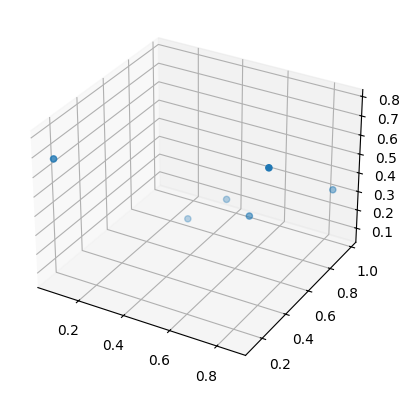

In [50]:
# visualize the embeddings in 3 dimensions
x, y, z = embedded_sequence[:, 0], embedded_sequence[:, 1], embedded_sequence[:, 2] 
ax = plt.axes(projection='3d')
ax.scatter3D(x, y, z) 

## Embeddings Using the PyTorch Module



In [51]:
# vocab size
vocab_size = len(stoi)


# embedding dimensions
d_model = 4

# create the embeddings
lut = nn.Embedding(vocab_size, d_model) # look-up table (lut)

# view the embeddings
lut.state_dict()['weight']

tensor([[ 1.0701,  1.3483, -1.6250,  0.7289],
        [-0.8022,  0.6237, -0.4477, -0.2975],
        [-0.1128, -0.1918, -1.1280,  0.0456],
        [-0.7410, -1.4081, -0.8723, -0.4905],
        [ 0.0204, -0.1208,  1.3819,  0.7268],
        [-0.2527, -0.4240, -0.1491, -0.6926],
        [-1.3790,  0.6610,  0.7841, -0.8545],
        [ 0.3091,  0.6896,  1.2660,  0.4210],
        [ 0.6527,  0.5705, -0.2411,  0.8034],
        [ 0.1357, -1.1832, -1.5767, -0.7279],
        [ 0.4299, -0.1853,  1.1061, -0.9863],
        [-0.9270,  1.7823,  1.5933,  0.7438],
        [ 1.4851,  0.7807, -1.1711, -0.4451],
        [-1.8669,  0.4539,  0.4283,  1.3817],
        [ 0.1681, -0.1064, -0.1715,  0.6174],
        [-0.2750, -0.7047,  1.6712,  0.2027],
        [-1.9956,  1.3143,  0.3406, -0.1612],
        [-1.3207,  1.0044, -0.3328, -1.4623],
        [ 0.5107,  0.3479,  0.8674, -0.9139],
        [-1.1114,  0.3250,  0.8314, -0.0626],
        [ 0.4375, -0.7197, -0.3389,  0.4942],
        [-0.0427, -1.5658, -1.1562

In [52]:
indices = torch.Tensor(sequence).long()

indices

tensor([19, 22, 24,  6,  1,  3])

## More than one sentences

In [53]:
# list of sequences (3, )
L = 5
sequences = ["The air grows super crisp",
             "and the world dons its.",
             "mornings paint the beautiful landscape"]

# tokenize the sequences
tokenized_sequences = [tokenize(seq) for seq in sequences]
tokenized_sequences

[['the', 'air', 'grows', 'super', 'crisp'],
 ['and', 'the', 'world', 'dons', 'its'],
 ['mornings', 'paint', 'the', 'beautiful', 'landscape']]

In [54]:
# index the sequences 
stoi = build_vocab(example)

indexed_sequences = [[stoi[word] for word in seq] for seq in tokenized_sequences]

indexed_sequences

[[22, 0, 10, 21, 6], [1, 22, 24, 8, 15], [17, 19, 22, 2, 16]]

In [55]:
# convert the sequences to a tensor
tensor_sequences = torch.tensor(indexed_sequences).long()

embedding_sequences = lut(tensor_sequences)
print(embedding_sequences.shape)
embedding_sequences


torch.Size([3, 5, 4])


tensor([[[ 1.3797, -0.0400, -0.0271, -0.1496],
         [ 1.0701,  1.3483, -1.6250,  0.7289],
         [ 0.4299, -0.1853,  1.1061, -0.9863],
         [-0.0427, -1.5658, -1.1562, -0.3794],
         [-1.3790,  0.6610,  0.7841, -0.8545]],

        [[-0.8022,  0.6237, -0.4477, -0.2975],
         [ 1.3797, -0.0400, -0.0271, -0.1496],
         [-1.0457,  2.5959,  0.1729,  0.3194],
         [ 0.6527,  0.5705, -0.2411,  0.8034],
         [-0.2750, -0.7047,  1.6712,  0.2027]],

        [[-1.3207,  1.0044, -0.3328, -1.4623],
         [-1.1114,  0.3250,  0.8314, -0.0626],
         [ 1.3797, -0.0400, -0.0271, -0.1496],
         [-0.1128, -0.1918, -1.1280,  0.0456],
         [-1.9956,  1.3143,  0.3406, -0.1612]]], grad_fn=<EmbeddingBackward0>)

In [ ]:
embedding_sequences.shape

torch.Size([3, 5, 4])

## The output will be a (3, 5, 4) matrix, which correlates to (batch_size, seq_length, d_model).

# Now you can create a new layer in PyTorch for Embedding

In [56]:
class Embeddings(nn.Module):
  def __init__(self, vocab_size: int, d_model: int):
    """
    Args:
      vocab_size:     size of vocabulary
      d_model:        dimension of embeddings
    """
    # inherit from nn.Module
    super().__init__()   
     
    # embedding look-up table (lut)                          
    self.lut = nn.Embedding(vocab_size, d_model)   

    # dimension of embeddings 
    self.d_model = d_model                          

  def forward(self, x: Tensor):
    """
    Args:
      x:              input Tensor (batch_size, seq_length)
      
    Returns:
                      embedding vector
    """
    # embeddings by constant sqrt(d_model)
    return self.lut(x) * math.sqrt(self.d_model)
  

# embedding dimensions
d_model = 4

lut = Embeddings(vocab_size, d_model)

print(lut(indices))

sequences = ["The air grows crisp",
             "and the world dons.",
             "mornings paint the landscape"]

tokenized_sequences = [tokenize(seq) for seq in sequences]
print(tokenized_sequences)

indexed_sequences = [[stoi[word] for word in seq] for seq in tokenized_sequences]
print(indexed_sequences)

# convert the sequences to a tensor
tensor_sequences = torch.tensor(indexed_sequences).long()

embedding_sequences = lut(tensor_sequences)
print(embedding_sequences.shape)
print(embedding_sequences)

tensor([[-0.0639, -1.7948, -1.1647,  0.7277],
        [-0.3880, -2.8786,  0.3379,  2.8960],
        [ 1.3994, -0.4260, -3.3063, -1.8584],
        [-0.2179,  0.5224,  0.5694, -4.1118],
        [ 2.6010, -0.3400,  1.0123,  3.4768],
        [-2.4600, -1.9336, -2.8927,  0.7411]], grad_fn=<MulBackward0>)
[['the', 'air', 'grows', 'crisp'], ['and', 'the', 'world', 'dons'], ['mornings', 'paint', 'the', 'landscape']]
[[22, 0, 10, 6], [1, 22, 24, 8], [17, 19, 22, 16]]
torch.Size([3, 4, 4])
tensor([[[-0.3880, -2.8786,  0.3379,  2.8960],
         [-0.0737,  0.2970, -3.6728, -1.6268],
         [ 0.2770,  1.1364, -0.7641,  0.5642],
         [-0.2179,  0.5224,  0.5694, -4.1118]],

        [[ 2.6010, -0.3400,  1.0123,  3.4768],
         [-0.3880, -2.8786,  0.3379,  2.8960],
         [ 1.3994, -0.4260, -3.3063, -1.8584],
         [ 1.3438,  2.7302,  1.9650,  1.6702]],

        [[ 3.8166,  1.3580,  0.7545, -3.3575],
         [-0.0639, -1.7948, -1.1647,  0.7277],
         [-0.3880, -2.8786,  0.3379,  2.8

# Positional Encoding

The output below embeds four sequences with a `d_model` of 4.

In [57]:
# set the output to 2 decimal places without scientific notation
torch.set_printoptions(precision=2, sci_mode=False)

# tokenize the sequences
tokenized_sequences = [tokenize(seq) for seq in sequences]

# index the sequences 
indexed_sequences = [[stoi[word] for word in seq] for seq in tokenized_sequences]

# convert the sequences to a tensor
tensor_sequences = torch.tensor(indexed_sequences).long()

# vocab size
vocab_size = len(stoi)

# embedding dimensions
d_model = 4

# create the embeddings
lut = nn.Embedding(vocab_size, d_model) # look-up table (lut)

# embed the sequence
embeddings = lut(tensor_sequences)

embeddings

tensor([[[ 0.47, -0.52, -0.60,  1.27],
         [-0.74, -0.21, -1.95,  1.45],
         [-0.10,  1.07,  0.21, -1.58],
         [-0.75, -0.12,  0.31,  0.97]],

        [[ 0.02, -0.77,  1.71, -1.38],
         [ 0.47, -0.52, -0.60,  1.27],
         [ 0.80,  0.95,  0.27, -0.08],
         [-1.13, -1.10, -1.06, -0.26]],

        [[-0.48, -0.39,  0.42,  0.67],
         [ 0.08,  1.60, -2.02,  0.67],
         [ 0.47, -0.52, -0.60,  1.27],
         [ 0.18,  0.00, -1.74, -1.86]]], grad_fn=<EmbeddingBackward0>)

In [58]:
# maximum sequence length
L = 5
n = 100

def gen_pe(max_length, d_model, n):

  # generate an empty matrix for the positional encodings (pe)
  pe = np.zeros(max_length*d_model).reshape(max_length, d_model) 

  # for each position
  for k in np.arange(max_length):

    # for each dimension
    for i in np.arange(d_model//2):

      # calculate the internal value for sin and cos
      theta = k / (n ** ((2*i)/d_model))       

      # even dims: sin   
      pe[k, 2*i] = math.sin(theta) 

      # odd dims: cos               
      pe[k, 2*i+1] = math.cos(theta)

  return pe



encodings = gen_pe(L, d_model, n)
print(encodings.shape)
encodings

(5, 4)


array([[ 0.        ,  1.        ,  0.        ,  1.        ],
       [ 0.84147098,  0.54030231,  0.09983342,  0.99500417],
       [ 0.90929743, -0.41614684,  0.19866933,  0.98006658],
       [ 0.14112001, -0.9899925 ,  0.29552021,  0.95533649],
       [-0.7568025 , -0.65364362,  0.38941834,  0.92106099]])

In [59]:
# select the first six tokens
seq_length = embeddings.shape[1]
print(seq_length)
encodings[:seq_length]

4


array([[ 0.        ,  1.        ,  0.        ,  1.        ],
       [ 0.84147098,  0.54030231,  0.09983342,  0.99500417],
       [ 0.90929743, -0.41614684,  0.19866933,  0.98006658],
       [ 0.14112001, -0.9899925 ,  0.29552021,  0.95533649]])

In [60]:
positional_encoding = embedding_sequences.detach().numpy() + encodings[:seq_length]
print(positional_encoding.shape)
positional_encoding

(3, 4, 4)


array([[[-0.38799441, -1.87857103,  0.33787274,  3.89595819],
        [ 0.76775831,  0.83734667, -3.5729471 , -0.63179518],
        [ 1.1862941 ,  0.72028998, -0.56546776,  1.54421924],
        [-0.07678834, -0.46760857,  0.86496367, -3.1565133 ]],

       [[ 2.60101652,  0.66002771,  1.01228893,  4.47681403],
        [ 0.45347658, -2.33826873,  0.43770616,  3.89096235],
        [ 2.30865379, -0.84211578, -3.107612  , -0.87835952],
        [ 1.48488801,  1.74024928,  2.26056018,  2.62557332]],

       [[ 3.816576  ,  2.35803676,  0.75448203, -2.3574965 ],
        [ 0.77754403, -1.25447568, -1.06482561,  1.72274225],
        [ 0.52130302, -3.29471787,  0.53654207,  3.87602476],
        [-2.23021741, -1.18994404, -0.7863662 ,  0.10564438]]])

## Visualize the position encoding


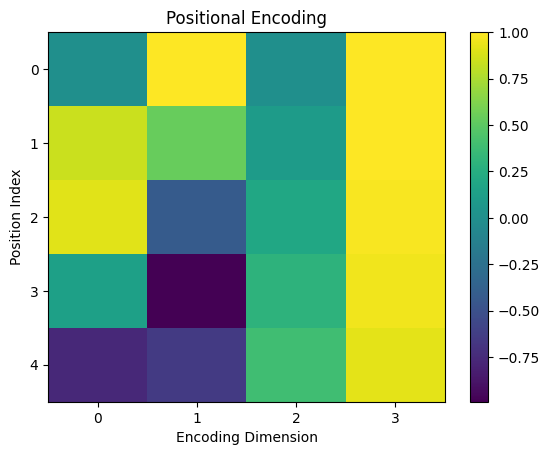

In [61]:
def visualize_pe(max_length, d_model, n):
  plt.imshow(gen_pe(max_length, d_model, n), aspect="auto")
  plt.title("Positional Encoding")
  plt.xlabel("Encoding Dimension")
  plt.ylabel("Position Index")

  # set the tick marks for the axes
  if d_model < 10:
    plt.xticks(torch.arange(0, d_model))
  if max_length < 20:
    plt.yticks(torch.arange(max_length-1, -1, -1))
    
  plt.colorbar()
  plt.show()

# plot the encodings
max_length = 5
d_model = 4
n = 100

visualize_pe(max_length, d_model, n)

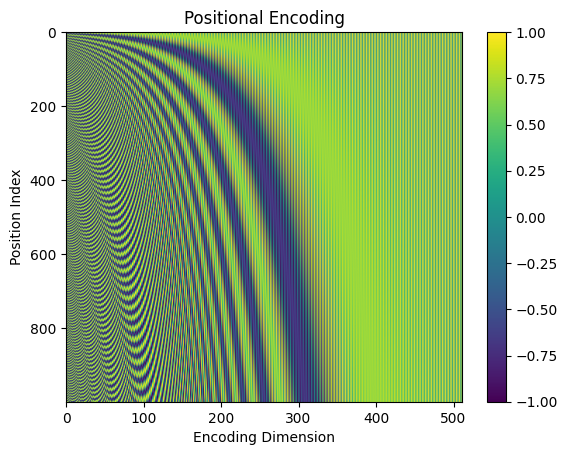

In [62]:
# plot the encodings
max_length = 1000
d_model = 512
n = 10000

visualize_pe(max_length, d_model, n)

# Now we can put together them to create a custom Layer for PositionalEncoding

In [63]:
# class PositionalEncoding(nn.Module):
#   def __init__(self, d_model: int, dropout: float = 0.1, max_length: int = 5000):
#     """
#     Args:
#       d_model:      dimension of embeddings
#       dropout:      randomly zeroes-out some of the input
#       max_length:   max sequence length
#     """
#     # inherit from Module
#     super().__init__()     

#     # initialize dropout                  
#     self.dropout = nn.Dropout(p=dropout)      

#     # create tensor of 0s
#     pe = torch.zeros(max_length, d_model)

#     # for each position
#     for k in np.arange(max_length):

#       # for each dimension
#       for i in np.arange(d_model//2):

#         # calculate the internal value for sin and cos
#         theta = k / (n ** ((2*i)/d_model))       

#         # even dims: sin   
#         pe[k, 2*i] = math.sin(theta) 

#         # odd dims: cos               
#         pe[k, 2*i+1] = math.cos(theta)

#         # buffers are saved in state_dict but not trained by the optimizer                        
#     self.register_buffer("pe", pe)                        

#   def forward(self, x: Tensor):
#     """
#     Args:
#       x:        embeddings (batch_size, seq_length, d_model)
    
#     Returns:
#                 embeddings + positional encodings (batch_size, seq_length, d_model)
#     """
#     # add positional encoding to the embeddings
#     x = x + self.pe[:, : x.size(1)].requires_grad_(False) 

#     # perform dropout
#     return self.dropout(x)
  

print(embeddings)

d_model = 4
max_length = 5
dropout = 0.0

class PositionalEncoding(nn.Module):
  def __init__(self, d_model: int, dropout: float = 0.1, max_length: int = 5000):
    """
    Args:
      d_model:      dimension of embeddings
      dropout:      randomly zeroes-out some of the input
      max_length:   max sequence length
    """
    # inherit from Module
    super().__init__()     

    # initialize dropout                  
    self.dropout = nn.Dropout(p=dropout)      

    # create tensor of 0s
    pe = torch.zeros(max_length, d_model)    

    # create position column   
    k = torch.arange(0, max_length).unsqueeze(1)  

    # calc divisor for positional encoding 
    div_term = torch.exp(                                 
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
    )

    # calc sine on even indices
    pe[:, 0::2] = torch.sin(k * div_term)    

    # calc cosine on odd indices   
    pe[:, 1::2] = torch.cos(k * div_term)  

    # add dimension     
    pe = pe.unsqueeze(0)          

    # buffers are saved in state_dict but not trained by the optimizer                        
    self.register_buffer("pe", pe)                        

  def forward(self, x: Tensor):
    """
    Args:
      x:        embeddings (batch_size, seq_length, d_model)
    
    Returns:
                embeddings + positional encodings (batch_size, seq_length, d_model)
    """
    # add positional encoding to the embeddings
    x = x + self.pe[:, : x.size(1)].requires_grad_(False) 

    # perform dropout
    return self.dropout(x)


# create the positional encoding matrix
pe = PositionalEncoding(d_model, dropout, max_length)

# preview the values

print(pe.state_dict())

print(pe(embeddings))

tensor([[[ 0.47, -0.52, -0.60,  1.27],
         [-0.74, -0.21, -1.95,  1.45],
         [-0.10,  1.07,  0.21, -1.58],
         [-0.75, -0.12,  0.31,  0.97]],

        [[ 0.02, -0.77,  1.71, -1.38],
         [ 0.47, -0.52, -0.60,  1.27],
         [ 0.80,  0.95,  0.27, -0.08],
         [-1.13, -1.10, -1.06, -0.26]],

        [[-0.48, -0.39,  0.42,  0.67],
         [ 0.08,  1.60, -2.02,  0.67],
         [ 0.47, -0.52, -0.60,  1.27],
         [ 0.18,  0.00, -1.74, -1.86]]], grad_fn=<EmbeddingBackward0>)
OrderedDict({'pe': tensor([[[ 0.00,  1.00,  0.00,  1.00],
         [ 0.84,  0.54,  0.01,  1.00],
         [ 0.91, -0.42,  0.02,  1.00],
         [ 0.14, -0.99,  0.03,  1.00],
         [-0.76, -0.65,  0.04,  1.00]]])})
tensor([[[ 0.47,  0.48, -0.60,  2.27],
         [ 0.10,  0.33, -1.94,  2.45],
         [ 0.81,  0.65,  0.23, -0.58],
         [-0.61, -1.11,  0.34,  1.97]],

        [[ 0.02,  0.23,  1.71, -0.38],
         [ 1.31,  0.02, -0.59,  2.27],
         [ 1.71,  0.54,  0.29,  0.92],
   

# Multi-head Attention

In [64]:
lut = Embeddings(vocab_size=len(stoi), d_model=4)
pe = PositionalEncoding(d_model=4, dropout=0.1, max_length=L)
embeddings = lut(tensor_sequences)
X = pe(embeddings)
print(X)
print(X.shape)

tensor([[[-1.51,  1.68, -1.77, -0.12],
         [ 0.27,  2.79,  0.20,  2.45],
         [ 0.41, -0.00, -0.80,  0.77],
         [ 0.60,  2.38, -1.60,  0.53]],

        [[ 2.00,  0.59, -0.95,  1.99],
         [-0.57,  1.17, -1.76, -0.12],
         [ 2.87, -0.31,  1.37,  4.02],
         [ 1.30, -0.18,  0.53,  0.77]],

        [[-1.01,  5.15, -0.37, -0.00],
         [-1.85,  2.95, -0.11,  3.55],
         [-0.00,  0.11, -1.74, -0.12],
         [ 2.14, -0.00,  0.08,  0.34]]], grad_fn=<MulBackward0>)
torch.Size([3, 4, 4])


## Let's create linear layer specifying Weights for Query, Key and Values

In [65]:
Wq = nn.Linear(d_model, d_model)          # query weights (4,4)
Wk = nn.Linear(d_model, d_model)          # key weights   (4,4)
Wv = nn.Linear(d_model, d_model)          # value weights (4,4)

Wq.state_dict()['weight']

tensor([[-0.08,  0.15,  0.28,  0.07],
        [ 0.50,  0.37, -0.50,  0.11],
        [-0.12, -0.47,  0.13,  0.23],
        [ 0.25,  0.32,  0.03, -0.25]])

In [66]:
Q = Wq(X) # (3,4,4)x(broadcast 4,4) = (3,4,4)
K = Wk(X) # (3,4,4)x(broadcast 4,4) = (3,4,4)
V = Wv(X) # (3,4,4)x(broadcast 4,4) = (3,4,4)

print(Q.shape)
print(Q)

torch.Size([3, 4, 4])
tensor([[[-0.00,  1.09, -0.66, -0.34],
         [ 0.74,  1.70, -0.57, -0.13],
         [-0.08,  1.04,  0.22, -0.59],
         [ 0.02,  2.38, -1.08,  0.26]],

        [[-0.08,  2.26,  0.01, -0.32],
         [-0.15,  1.36, -0.53, -0.26],
         [ 0.50,  1.44,  1.08, -0.84],
         [ 0.20,  0.76,  0.36, -0.39]],

        [[ 0.87,  1.93, -2.15,  0.91],
         [ 0.92,  0.98, -0.17, -0.90],
         [-0.35,  1.24, -0.10, -0.46],
         [ 0.00,  1.42,  0.02, -0.02]]], grad_fn=<ViewBackward0>)


With the Q, K, and V tensors created, they can now be split into their respective heads by changing the view of d_model to (n_heads, d_key). n_heads can be an arbitrary number, but it is common to do 8, 10, or 12 when working with larger embeddings. Remember that d_key = (d_model / n_heads).

The shape of each tensor becomes:

(batch_size, seq_length, d_model) → (batch_size, seq_length, n_heads, d_key)

We will just keep n_heads = 2

In [67]:
batch_size = Q.size(0)   
n_heads = 2
d_key = d_model//n_heads # 4/2 = 2


Q = Q.view(batch_size, -1, n_heads, d_key)

K = K.view(batch_size, -1, n_heads, d_key)

V = V.view(batch_size, -1, n_heads, d_key)                   

print(Q)
print(Q.shape)

tensor([[[[-0.00,  1.09],
          [-0.66, -0.34]],

         [[ 0.74,  1.70],
          [-0.57, -0.13]],

         [[-0.08,  1.04],
          [ 0.22, -0.59]],

         [[ 0.02,  2.38],
          [-1.08,  0.26]]],


        [[[-0.08,  2.26],
          [ 0.01, -0.32]],

         [[-0.15,  1.36],
          [-0.53, -0.26]],

         [[ 0.50,  1.44],
          [ 1.08, -0.84]],

         [[ 0.20,  0.76],
          [ 0.36, -0.39]]],


        [[[ 0.87,  1.93],
          [-2.15,  0.91]],

         [[ 0.92,  0.98],
          [-0.17, -0.90]],

         [[-0.35,  1.24],
          [-0.10, -0.46]],

         [[ 0.00,  1.42],
          [ 0.02, -0.02]]]], grad_fn=<ViewBackward0>)
torch.Size([3, 4, 2, 2])


To proceed, it would be best to transpose seq_length and n_heads, the second and third dimensions, to have the following shape:

(batch_size, seq_length, n_heads, d_key) → (batch_size, n_heads, seq_length, d_key)
Now, each sequence is split across n_heads, with each head receiving seq_length tokens with d_key elements in each token instead of d_model. This achieves the researchers’ goal to “attend to information from different representation subspaces at different positions.”

To return to the previous example, the Q tensor would be transposed from  (3, 4, 2, 2) to (3, 2, 4, 2)

In [68]:
# query tensor | (3, 4, 2, 2) to (3, 2, 4, 2)
print(Q.shape)
Q = Q.permute(0, 2, 1, 3)
# key tensor | (3, 4, 2, 2) to (3, 2, 4, 2)
K = K.permute(0, 2, 1, 3)
# value tensor | (3, 4, 2, 2) to (3, 2, 4, 2)
V = V.permute(0, 2, 1, 3)
print(Q)
print(Q.shape)

torch.Size([3, 4, 2, 2])
tensor([[[[-0.00,  1.09],
          [ 0.74,  1.70],
          [-0.08,  1.04],
          [ 0.02,  2.38]],

         [[-0.66, -0.34],
          [-0.57, -0.13],
          [ 0.22, -0.59],
          [-1.08,  0.26]]],


        [[[-0.08,  2.26],
          [-0.15,  1.36],
          [ 0.50,  1.44],
          [ 0.20,  0.76]],

         [[ 0.01, -0.32],
          [-0.53, -0.26],
          [ 1.08, -0.84],
          [ 0.36, -0.39]]],


        [[[ 0.87,  1.93],
          [ 0.92,  0.98],
          [-0.35,  1.24],
          [ 0.00,  1.42]],

         [[-2.15,  0.91],
          [-0.17, -0.90],
          [-0.10, -0.46],
          [ 0.02, -0.02]]]], grad_fn=<PermuteBackward0>)
torch.Size([3, 2, 4, 2])


In [69]:
Q[0]

tensor([[[-0.00,  1.09],
         [ 0.74,  1.70],
         [-0.08,  1.04],
         [ 0.02,  2.38]],

        [[-0.66, -0.34],
         [-0.57, -0.13],
         [ 0.22, -0.59],
         [-1.08,  0.26]]], grad_fn=<SelectBackward0>)

In [70]:
# calculate scaled dot product
scaled_dot_prod = torch.matmul(Q, K.permute(0, 1, 3, 2)) / math.sqrt(d_key) # (batch_size, n_heads, Q_length, K_length)

In [71]:
# apply softmax to get context for each token and others
attn_probs = torch.softmax(scaled_dot_prod, dim=-1) # (batch_size, n_heads, Q_length, K_length)

In [ ]:
# def display_attention(sentence: list, translation: list, attention: Tensor, 
#                       n_heads: int = 8, n_rows: int = 4, n_cols: int = 2):
#   """
#     Display the attention matrix for each head of a sequence.

#     Args:
#         sentence:     German sentence to be translated to English; list
#         translation:  English sentence predicted by the model
#         attention:    attention scores for the heads
#         n_heads:      number of heads
#         n_rows:       number of rows
#         n_cols:       number of columns
#   """
#   # ensure the number of rows and columns are equal to the number of heads
#   assert n_rows * n_cols == n_heads
    
#   # figure size
#   fig = plt.figure(figsize=(15,20))
    
#   # visualize each head
#   for i in range(n_heads):
        
#     # create a plot
#     ax = fig.add_subplot(n_rows, n_cols, i+1)
        
#     # select the respective head and make it a numpy array for plotting
#     _attention = attention.squeeze(0)[i,:,:].cpu().detach().numpy()

#     # plot the matrix
#     cax = ax.matshow(_attention, cmap='bone')

#     # set the size of the labels
#     ax.tick_params(labelsize=12)

#     # set the indices for the tick marks
#     ax.set_xticks(range(len(sentence)))
#     ax.set_yticks(range(len(translation)))

#     ax.set_xticklabels(sentence)
#     ax.set_yticklabels(translation)

#   plt.show()

In [ ]:
# # sequence 0
# display_attention(["The", "air", "grows", "crisp"], 
#                  ["The", "air", "grows", "crisp"], 
#                   attn_probs[0], 1, 1, 1)

In [72]:
# multiply attention and values to get reweighted values
A = torch.matmul(attn_probs, V) # (batch_size, n_heads, Q_length, d_key)


In [73]:
print(A.shape)
print(A)

torch.Size([3, 2, 4, 2])
tensor([[[[ 0.43,  0.79],
          [ 0.54,  0.86],
          [ 0.41,  0.79],
          [ 0.57,  1.05]],

         [[-0.41,  0.59],
          [-0.41,  0.57],
          [-0.38,  0.57],
          [-0.43,  0.56]]],


        [[[-0.71,  1.00],
          [-0.74,  1.03],
          [-0.57,  0.78],
          [-0.66,  0.91]],

         [[-0.03,  1.18],
          [-0.01,  1.19],
          [-0.02,  1.32],
          [-0.05,  1.18]]],


        [[[ 1.26,  1.06],
          [ 1.31,  1.09],
          [ 1.17,  1.04],
          [ 1.26,  1.07]],

         [[-1.02,  0.05],
          [-0.35,  0.54],
          [-0.37,  0.52],
          [-0.40,  0.50]]]], grad_fn=<UnsafeViewBackward0>)


## Passing It Through the Output Layer

At this point, the heads can be concatenated back together before they are passed through the final linear layer, Wo in the multi-head attention mechanism.

The concatenation reverses the split that was performed originally. The first step is to transpose n_heads and Q_length. The second step is to concatenate n_heads and d_key back together to get d_model.

Once this is complete, A will have a shape of (batch_size, Q_length, d_model).



In [74]:
A = A.permute(0, 2, 1, 3).contiguous()


# reshape from (3, 4, 2, 2) -> (3, 4, 4) = (batch_size, Q_length, d_model)
A = A.view(batch_size, -1, n_heads*d_key)

print(A.shape)
print(A)

torch.Size([3, 4, 4])
tensor([[[ 0.43,  0.79, -0.41,  0.59],
         [ 0.54,  0.86, -0.41,  0.57],
         [ 0.41,  0.79, -0.38,  0.57],
         [ 0.57,  1.05, -0.43,  0.56]],

        [[-0.71,  1.00, -0.03,  1.18],
         [-0.74,  1.03, -0.01,  1.19],
         [-0.57,  0.78, -0.02,  1.32],
         [-0.66,  0.91, -0.05,  1.18]],

        [[ 1.26,  1.06, -1.02,  0.05],
         [ 1.31,  1.09, -0.35,  0.54],
         [ 1.17,  1.04, -0.37,  0.52],
         [ 1.26,  1.07, -0.40,  0.50]]], grad_fn=<ViewBackward0>)


The final step is to pass A through Wo, which has a shape of (d_model, d_model).

In [75]:
Wo = nn.Linear(d_model, d_model)

# (3, 4, 3) x (broadcast 3, 3) = (3, 4, 3)
output = Wo(A)  
print(output)

tensor([[[-0.37, -0.12,  0.18, -0.02],
         [-0.36, -0.08,  0.08, -0.02],
         [-0.37, -0.12,  0.17, -0.03],
         [-0.44, -0.05, -0.01, -0.05]],

        [[-0.83, -0.51,  0.71, -0.07],
         [-0.85, -0.52,  0.70, -0.08],
         [-0.68, -0.55,  0.82,  0.04],
         [-0.78, -0.51,  0.74, -0.05]],

        [[-0.33,  0.23, -0.34, -0.12],
         [-0.12,  0.12, -0.39,  0.11],
         [-0.16,  0.09, -0.30,  0.08],
         [-0.15,  0.12, -0.36,  0.08]]], grad_fn=<ViewBackward0>)


## Now we can create a layer to implement everything we discussed about a Multi-head Attention

In [76]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model: int = 512, n_heads: int = 8, dropout: float = 0.1):
    """
    Args:
        d_model:      dimension of embeddings
        n_heads:      number of self attention heads
        dropout:      probability of dropout occurring
    """
    super().__init__()
    assert d_model % n_heads == 0            # ensure an even num of heads
    self.d_model = d_model                   # 512 dim
    self.n_heads = n_heads                   # 8 heads
    self.d_key = d_model // n_heads          # assume d_value equals d_key | 512/8=64

    self.Wq = nn.Linear(d_model, d_model)    # query weights
    self.Wk = nn.Linear(d_model, d_model)    # key weights
    self.Wv = nn.Linear(d_model, d_model)    # value weights
    self.Wo = nn.Linear(d_model, d_model)    # output weights

    self.dropout = nn.Dropout(p=dropout)     # initialize dropout layer  

  def forward(self, query: Tensor, key: Tensor, value: Tensor, mask: Tensor = None):
    """
    Args:
       query:         query vector         (batch_size, q_length, d_model)
       key:           key vector           (batch_size, k_length, d_model)
       value:         value vector         (batch_size, s_length, d_model)
       mask:          mask for decoder     

    Returns:
       output:        attention values     (batch_size, q_length, d_model)
       attn_probs:    softmax scores       (batch_size, n_heads, q_length, k_length)
    """
    batch_size = key.size(0)                  
        
    # calculate query, key, and value tensors
    Q = self.Wq(query)                       # (32, 10, 512) x (512, 512) = (32, 10, 512)
    K = self.Wk(key)                         # (32, 10, 512) x (512, 512) = (32, 10, 512)
    V = self.Wv(value)                       # (32, 10, 512) x (512, 512) = (32, 10, 512)

    # split each tensor into n-heads to compute attention

    # query tensor
    Q = Q.view(batch_size,                   # (32, 10, 512) -> (32, 10, 8, 64) 
               -1,                           # -1 = q_length
               self.n_heads,              
               self.d_key
               ).permute(0, 2, 1, 3)         # (32, 10, 8, 64) -> (32, 8, 10, 64) = (batch_size, n_heads, q_length, d_key)
    # key tensor
    K = K.view(batch_size,                   # (32, 10, 512) -> (32, 10, 8, 64) 
               -1,                           # -1 = k_length
               self.n_heads,              
               self.d_key
               ).permute(0, 2, 1, 3)         # (32, 10, 8, 64) -> (32, 8, 10, 64) = (batch_size, n_heads, k_length, d_key)
    # value tensor
    V = V.view(batch_size,                   # (32, 10, 512) -> (32, 10, 8, 64) 
               -1,                           # -1 = v_length
               self.n_heads, 
               self.d_key
               ).permute(0, 2, 1, 3)         # (32, 10, 8, 64) -> (32, 8, 10, 64) = (batch_size, n_heads, v_length, d_key)
       
    # computes attention
    # scaled dot product -> QK^{T}
    scaled_dot_prod = torch.matmul(Q,        # (32, 8, 10, 64) x (32, 8, 64, 10) -> (32, 8, 10, 10) = (batch_size, n_heads, q_length, k_length)
                                   K.permute(0, 1, 3, 2)
                                   ) / math.sqrt(self.d_key)      # sqrt(64)
        
    # fill those positions of product as (-1e10) where mask positions are 0
    if mask is not None:
      scaled_dot_prod = scaled_dot_prod.masked_fill(mask == 0, -1e10)

    # apply softmax 
    attn_probs = torch.softmax(scaled_dot_prod, dim=-1)
        
    # multiply by values to get attention
    A = torch.matmul(self.dropout(attn_probs), V)       # (32, 8, 10, 10) x (32, 8, 10, 64) -> (32, 8, 10, 64)
                                                        # (batch_size, n_heads, q_length, k_length) x (batch_size, n_heads, v_length, d_key) -> (batch_size, n_heads, q_length, d_key)

    # reshape attention back to (32, 10, 512)
    A = A.permute(0, 2, 1, 3).contiguous()              # (32, 8, 10, 64) -> (32, 10, 8, 64)
    A = A.view(batch_size, -1, self.n_heads*self.d_key) # (32, 10, 8, 64) -> (32, 10, 8*64) -> (32, 10, 512) = (batch_size, q_length, d_model)
        
    # push through the final weight layer
    output = self.Wo(A)                                 # (32, 10, 512) x (512, 512) = (32, 10, 512) 

    return output, attn_probs                           # return attn_probs for visualization of the scores

In [77]:
torch.set_printoptions(precision=2, sci_mode=False)


# embedding dimensions
d_model = 4

# create the embeddings
lut = Embeddings(vocab_size, d_model) # look-up table (lut)

# create the positional encodings
pe = PositionalEncoding(d_model=d_model, dropout=0.1, max_length=L)

# embed the sequence
embeddings = lut(tensor_sequences)

# positionally encode the sequences
X = pe(embeddings)

# set the n_heads
n_heads = 2

# create the attention layer
attention = MultiHeadAttention(d_model, n_heads, dropout=0.1)

# pass X through the attention layer three times to create Q, K, and V
output, attn_probs = attention(X, X, X, mask=None)

output

tensor([[[-0.18, -0.92, -1.22, -0.16],
         [ 0.30,  0.73,  0.56,  0.42],
         [ 0.08, -0.47, -0.53, -0.08],
         [ 0.11, -0.35, -0.40, -0.00]],

        [[ 0.28,  0.09,  0.44,  0.45],
         [ 0.12, -0.15,  0.06,  0.11],
         [ 0.14, -0.15,  0.17,  0.32],
         [ 0.01, -0.25,  0.09,  0.52]],

        [[-0.11, -0.26, -0.23,  0.39],
         [ 0.40, -0.13,  0.06, -0.17],
         [-0.59, -1.02, -0.97,  0.57],
         [ 0.52,  0.16,  0.35, -0.14]]], grad_fn=<ViewBackward0>)

# Position-wise Feed-forward Network

The Position-Wise Feed-Forward Network (FFN) consists of two fully connected dense layers, or a multi-layer perceptron (MLP). The hidden layer, which is known as d_ffn, is generally set to a value about four times that of d_model. This is why it is sometimes known as an expand-and-contract network.

According to d2l, it is known as a “position-wise” network because it “transforms the representation at all the sequence positions using the same MLP.”

The ReLU activiation function, max(0, X), is used between the layers. Any values greater than 0 remain the same, and any values less than or equal to 0 become 0. It introduces non-linearity and helps prevent vanishing gradients.

In [78]:
d_ffn = d_model * 4  # 4

w_1 = nn.Linear(d_model, d_ffn)  # (1, 4)
w_2 = nn.Linear(d_ffn, d_model)  # (4, 1)

ffn_1 = w_1(output).relu()
print(ffn_1.shape)
print(ffn_1)

torch.Size([3, 4, 16])
tensor([[[0.00, 0.00, 0.00, 0.21, 0.68, 0.00, 0.25, 0.00, 0.31, 0.00, 0.22,
          0.00, 0.07, 0.16, 0.62, 0.11],
         [0.00, 0.08, 0.25, 0.00, 0.00, 0.00, 0.00, 0.08, 0.04, 0.29, 0.18,
          0.00, 0.00, 0.00, 0.00, 0.00],
         [0.00, 0.00, 0.00, 0.00, 0.47, 0.00, 0.00, 0.00, 0.08, 0.00, 0.11,
          0.00, 0.00, 0.05, 0.39, 0.01],
         [0.00, 0.00, 0.00, 0.00, 0.39, 0.00, 0.00, 0.00, 0.05, 0.00, 0.12,
          0.00, 0.00, 0.02, 0.32, 0.00]],

        [[0.00, 0.00, 0.12, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.32, 0.16,
          0.00, 0.00, 0.00, 0.01, 0.00],
         [0.00, 0.00, 0.02, 0.00, 0.14, 0.00, 0.00, 0.00, 0.00, 0.09, 0.08,
          0.00, 0.00, 0.06, 0.20, 0.00],
         [0.00, 0.00, 0.06, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.20, 0.15,
          0.00, 0.00, 0.04, 0.15, 0.00],
         [0.00, 0.00, 0.07, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.27, 0.27,
          0.00, 0.00, 0.07, 0.15, 0.00]],

        [[0.00, 0.00, 0.05, 0.03, 0.0

Then, the tensor can be passed through the second dense layer to return to its normal size

In [79]:
ffn_2 = w_2(ffn_1)
print(ffn_2.shape)
print(ffn_2)

torch.Size([3, 4, 4])
tensor([[[-0.15, -0.04,  0.01, -0.04],
         [-0.09, -0.01,  0.01,  0.13],
         [-0.12,  0.04,  0.03,  0.02],
         [-0.13,  0.05,  0.02,  0.02]],

        [[-0.08,  0.01,  0.02,  0.09],
         [-0.11,  0.05,  0.04,  0.07],
         [-0.10,  0.03,  0.05,  0.08],
         [-0.11,  0.03,  0.06,  0.06]],

        [[-0.12,  0.01,  0.05,  0.06],
         [-0.12,  0.06,  0.00,  0.05],
         [-0.21, -0.07,  0.10,  0.00],
         [-0.10,  0.05, -0.01,  0.07]]], grad_fn=<ViewBackward0>)


## We can create a new layer combining everything in the position-wise feed-forward layer

In [80]:
class PositionwiseFeedForward(nn.Module):
  def __init__(self, d_model: int, d_ffn: int, dropout: float = 0.1):
    """
    Args:
        d_model:      dimension of embeddings
        d_ffn:        dimension of feed-forward network
        dropout:      probability of dropout occurring
    """
    super().__init__()

    self.w_1 = nn.Linear(d_model, d_ffn)
    self.w_2 = nn.Linear(d_ffn, d_model)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    """
    Args:
        x:            output from attention (batch_size, seq_length, d_model)
       
    Returns:
        expanded-and-contracted representation (batch_size, seq_length, d_model)
    """
    # w_1(x).relu(): (batch_size, seq_length, d_model) x (d_model,d_ffn) -> (batch_size, seq_length, d_ffn)
    # w_2(w_1(x).relu()): (batch_size, seq_length, d_ffn) x (d_ffn, d_model) -> (batch_size, seq_length, d_model) 
    return self.w_2(self.dropout(self.w_1(x).relu()))

In [81]:
# pass the tensor through the position-wise feed-forward network
ffn = PositionwiseFeedForward(d_model, d_ffn, dropout=0.1)

ffn(output)


tensor([[[ 0.22, -0.16,  0.35,  0.22],
         [ 0.40, -0.07,  0.28,  0.28],
         [ 0.24, -0.17,  0.20,  0.13],
         [ 0.33, -0.15,  0.27,  0.15]],

        [[ 0.34, -0.04,  0.23,  0.10],
         [ 0.25, -0.05,  0.23,  0.15],
         [ 0.31, -0.10,  0.22,  0.09],
         [ 0.28, -0.07,  0.29,  0.06]],

        [[ 0.24, -0.10,  0.28,  0.08],
         [ 0.49, -0.13,  0.27,  0.19],
         [ 0.14, -0.21,  0.52,  0.22],
         [ 0.54, -0.13,  0.27,  0.24]]], grad_fn=<ViewBackward0>)

# Layer-Normalization

In [82]:
class LayerNorm(nn.Module):

  def __init__(self, features, eps=1e-5):
    super().__init__()
    # initialize gamma to be all ones
    self.gamma = nn.Parameter(torch.ones(features)) 
    # initialize beta to be all zeros
    self.beta = nn.Parameter(torch.zeros(features)) 
    # initialize epsilon
    self.eps = eps

  def forward(self, src):
    # mean of the token embeddings
    mean = src.mean(-1, keepdim=True)        
    # variance of the token embeddings         
    var = src.var(-1, keepdim=True,unbiased=False)  
    # return the normalized value  
    return self.gamma * (src - mean) / torch.sqrt(var + self.eps) + self.beta 


# Encode Layer

## Taking everything from above, we can create an encoder super-layer

In [83]:
class EncoderLayer(nn.Module):  
  def __init__(self, d_model: int, n_heads: int, d_ffn: int, dropout: float):
    """
    Args:
        d_model:      dimension of embeddings
        n_heads:      number of heads
        d_ffn:        dimension of feed-forward network
        dropout:      probability of dropout occurring
    """
    super().__init__()
    # multi-head attention sublayer
    self.attention = MultiHeadAttention(d_model, n_heads, dropout)
    # layer norm for multi-head attention
    self.attn_layer_norm = nn.LayerNorm(d_model)

    # position-wise feed-forward network
    self.positionwise_ffn = PositionwiseFeedForward(d_model, d_ffn, dropout)
    # layer norm for position-wise ffn
    self.ffn_layer_norm = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout)

  def forward(self, src: Tensor, src_mask: Tensor):
    """
    Args:
        src:          positionally embedded sequences   (batch_size, seq_length, d_model)
        src_mask:     mask for the sequences            (batch_size, 1, 1, seq_length)
    Returns:
        src:          sequences after self-attention    (batch_size, seq_length, d_model)
    """
    # pass embeddings through multi-head attention
    _src, attn_probs = self.attention(src, src, src, src_mask)

    # residual add and norm
    src = self.attn_layer_norm(src + self.dropout(_src))
    
    # position-wise feed-forward network
    _src = self.positionwise_ffn(src)

    # residual add and norm
    src = self.ffn_layer_norm(src + self.dropout(_src)) 

    return src, attn_probs

# Encoder Stack: Multiple EncoderLayer Stacked Together

In [84]:
class Encoder(nn.Module):
  def __init__(self, d_model: int, n_layers: int, 
               n_heads: int, d_ffn: int, dropout: float = 0.1):
    """
    Args:
        d_model:      dimension of embeddings
        n_layers:     number of encoder layers
        n_heads:      number of heads
        d_ffn:        dimension of feed-forward network
        dropout:      probability of dropout occurring
    """
    super().__init__()
    
    # create n_layers encoders 
    self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ffn, dropout)
                                 for layer in range(n_layers)])

    self.dropout = nn.Dropout(dropout)
    
  def forward(self, src: Tensor, src_mask: Tensor):
    """
    Args:
        src:          embedded sequences                (batch_size, seq_length, d_model)
        src_mask:     mask for the sequences            (batch_size, 1, 1, seq_length)

    Returns:
        src:          sequences after self-attention    (batch_size, seq_length, d_model)
    """

    # pass the sequences through each encoder
    for layer in self.layers:
      src, attn_probs = layer(src, src_mask)

    self.attn_probs = attn_probs

    return src


In [85]:
# parameters
vocab_size = len(stoi)
d_model = 4
d_ffn = d_model*4 
n_heads = 1
n_layers = 4
dropout = 0.1

# create the embeddings
lut = Embeddings(vocab_size, d_model) # look-up table (lut)

# create the positional encodings
pe = PositionalEncoding(d_model=d_model, dropout=0.1, max_length=L)

# embed the sequence
embeddings = lut(tensor_sequences)

# positionally encode the sequences
X = pe(embeddings)

# initialize encoder
encoder = Encoder(d_model, n_layers, n_heads,
                  d_ffn, dropout)

# pass through encoder
enc = encoder(src=X, src_mask=None)
print(enc.shape)
print(enc)
# probabilities for sequence 0
print(encoder.attn_probs[0])

torch.Size([3, 4, 4])
tensor([[[-1.61,  0.23,  0.24,  1.14],
         [-1.50, -0.21,  0.52,  1.19],
         [-1.47, -0.35,  0.76,  1.06],
         [-1.52,  0.02,  0.22,  1.28]],

        [[-1.57, -0.04,  0.46,  1.15],
         [-1.42,  0.15, -0.12,  1.40],
         [-0.56, -0.62,  1.73, -0.55],
         [-0.45, -1.18,  1.55,  0.08]],

        [[-1.30,  0.66, -0.59,  1.23],
         [-1.36,  0.33, -0.35,  1.39],
         [-1.57,  0.25,  0.12,  1.20],
         [-1.49, -0.31,  0.68,  1.11]]], grad_fn=<NativeLayerNormBackward0>)
tensor([[[0.24, 0.24, 0.26, 0.26],
         [0.24, 0.24, 0.26, 0.26],
         [0.23, 0.24, 0.26, 0.26],
         [0.23, 0.25, 0.26, 0.26]]], grad_fn=<SelectBackward0>)


In the example above, the src_mask is set to None. As mentioned in the third article, an optional mask can be passed through the multi-head attention layer. For the encoder, this mask is often created based on the padding of the sequences. The three sequences used in this article are all of length 6. However, it is more likely that sequences of varying lengths will be in a batch. Padding is added to sequences to ensure all the sequences in a batch have the same length. When this occurs, the model does not need to pay attention to padding tokens. A mask vector is created for each sequence to reflect the values that should be attended to.

For example, the three sequences below have different lengths:

- ”What will come next?” → [21, 22, 5, 15]
- ”This is a basic paragraph.” → [20, 13, 0, 3, 17]
- ”A basic split will come next!” → [0, 3, 18, 22, 5, 15]

To be used in a tensor, they must be the same length, so padding must be added. This can be done using a simple function with pad from torch.nn.functional.

It allows every input to be padded to the same length. It requires:


- `seq`: a sequence
- `(0, pad_to_add)`: a tuple indicating the dimension to pad and by how much
- `value=pad_idx`: a value to use for the padding, which is normally an integer

This function can be used in a for-loop to pad a batch of sequences to the same length, which can be seen below. These padded sequences can be used as input to the encoder.

In [86]:
from torch.nn.functional import pad

def make_src_mask(src: Tensor, pad_idx: int = 0):
  """
  Args:
      src:          raw sequences with padding        (batch_size, seq_length)              
    
  Returns:
      src_mask:     mask for each sequence            (batch_size, 1, 1, seq_length)
  """
  # assign 1 to tokens that need attended to and 0 to padding tokens, then add 2 dimensions
  src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)

  return src_mask

def pad_seq(seq: Tensor, max_length: int = 10, pad_idx: int = 0):
  """
  Args:
      seq:          raw sequence (batch_size, seq_length)
      max_length:   maximum length of a sequence
      pad_idx:      index for padding tokens           
    
  Returns:
      padded seq:   padded sequence (batch_size, max_length)
  """
  pad_to_add = max_length - len(seq) # amount of padding to add
  
  return pad(seq,(0, pad_to_add), value=pad_idx,)


# This function is used to create a target mask for a padded sequence. The target mask allows a token to only attend to itself and any token before it.

def make_trg_mask(trg: Tensor, pad_idx: int = 0):
  """
  Args:
      trg:          raw sequences with padding        (batch_size, seq_length)              
    
  Returns:
      trg_mask:     mask for each sequence            (batch_size, 1, seq_length, seq_length)
  """

  seq_length = trg.shape[1]

  # assign True to tokens that need attended to and False to padding tokens, then add 2 dimensions
  trg_mask = (trg != pad_idx).unsqueeze(1).unsqueeze(2) # (batch_size, 1, 1, seq_length)

  # generate subsequent mask
  trg_sub_mask = torch.tril(torch.ones((seq_length, seq_length))).bool() # (batch_size, 1, seq_length, seq_length)

  # bitwise "and" operator | 0 & 0 = 0, 1 & 1 = 1, 1 & 0 = 0
  trg_mask = trg_mask & trg_sub_mask

  return trg_mask

In [87]:
max_length = 8
pad_idx = len(stoi)

padded_seqs = []

for seq in indexed_sequences:
  # pad each sequence
  padded_seqs.append(pad_seq(torch.Tensor(seq), max_length, pad_idx))

# create a tensor from the padded sequences
tensor_sequences = torch.stack(padded_seqs).long()

print(tensor_sequences)

# create the source masks for the sequences
src_mask = make_src_mask(tensor_sequences, pad_idx)

print(padded_seqs)


tensor([[22,  0, 10,  6, 25, 25, 25, 25],
        [ 1, 22, 24,  8, 25, 25, 25, 25],
        [17, 19, 22, 16, 25, 25, 25, 25]])
[tensor([22.,  0., 10.,  6., 25., 25., 25., 25.]), tensor([ 1., 22., 24.,  8., 25., 25., 25., 25.]), tensor([17., 19., 22., 16., 25., 25., 25., 25.])]


In [89]:
# parameters
vocab_size = len(stoi) + 1 # add one for the padding token
d_model = 8
d_ffn = d_model*4 # 32
n_heads = 4
n_layers = 4
dropout = 0.1

In [90]:
# create the embeddings
lut = Embeddings(vocab_size, d_model) # look-up table (lut)

# create the positional encodings
pe = PositionalEncoding(d_model=d_model, dropout=0.1, max_length=8)

# embed the sequence
embeddings = lut(tensor_sequences)

# positionally encode the sequences
X = pe(embeddings)

# initialize encoder
encoder = Encoder(d_model, n_layers, n_heads,
                  d_ffn, dropout)

# pass through encoder
encoder(src=X, src_mask=src_mask)

tensor([[[-1.31,  0.86,  1.12, -0.21, -1.60, -0.50,  1.07,  0.56],
         [-0.87,  1.24,  1.05,  1.31, -0.66,  0.12, -1.08, -1.11],
         [-0.70, -0.56, -0.08,  1.84, -0.19,  1.38, -0.38, -1.31],
         [-0.38, -0.36, -1.25,  0.84,  0.03,  2.00,  0.29, -1.17],
         [-0.05, -0.44, -1.53,  0.73,  1.77, -0.94, -0.41,  0.87],
         [-0.15,  0.02, -1.35, -0.09,  1.82, -0.26, -1.17,  1.19],
         [-0.26,  0.58, -0.80,  0.45,  1.69,  0.16, -1.97,  0.15],
         [-0.22,  0.55, -0.07, -0.48,  2.15,  0.16, -1.58, -0.52]],

        [[-1.25,  0.86,  1.14,  0.60, -1.84,  0.58, -0.45,  0.36],
         [ 0.08,  1.30,  0.13,  1.83, -0.71, -1.16, -0.88, -0.57],
         [ 0.49,  0.25,  0.45,  1.87, -1.50, -1.17,  0.20, -0.59],
         [ 0.69, -0.08,  0.11,  1.81,  0.04,  0.25, -1.09, -1.72],
         [-0.62,  0.32,  0.29,  0.75,  1.18,  0.84, -2.08, -0.68],
         [-0.33,  0.75,  0.41,  0.35,  0.52,  0.64, -2.52,  0.18],
         [ 0.41,  0.19,  0.34, -0.63, -0.37,  1.38, -2.14,  

# Decoder Layer

The decoder layer is nothing more than a wrapper for the sublayers. It implements two multi-head attention sublayers and a position-wise feed-forward network, each followed by layer normalization and residual addition.

In [91]:
class DecoderLayer(nn.Module):

  def __init__(self, d_model: int, n_heads: int, d_ffn: int, dropout: float):
    """
    Args:
        d_model:      dimension of embeddings
        n_heads:      number of heads
        d_ffn:        dimension of feed-forward network
        dropout:      probability of dropout occurring
    """
    super().__init__()
    # masked multi-head attention sublayer
    self.masked_attention = MultiHeadAttention(d_model, n_heads, dropout)
    # layer norm for masked multi-head attention
    self.masked_attn_layer_norm = nn.LayerNorm(d_model)

    # multi-head attention sublayer
    self.attention = MultiHeadAttention(d_model, n_heads, dropout)
    # layer norm for multi-head attention
    self.attn_layer_norm = nn.LayerNorm(d_model)
    
    # position-wise feed-forward network
    self.positionwise_ffn = PositionwiseFeedForward(d_model, d_ffn, dropout)
    # layer norm for position-wise ffn
    self.ffn_layer_norm = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout)

  def forward(self, trg: Tensor, src: Tensor, trg_mask: Tensor, src_mask: Tensor):
    """
    Args:
        trg:          embedded sequences                (batch_size, trg_seq_length, d_model)
        src:          embedded sequences                (batch_size, src_seq_length, d_model)
        trg_mask:     mask for the sequences            (batch_size, 1, trg_seq_length, trg_seq_length)
        src_mask:     mask for the sequences            (batch_size, 1, 1, src_seq_length)

    Returns:
        trg:          sequences after self-attention    (batch_size, trg_seq_length, d_model)
        attn_probs:   attention softmax scores
    """
    # pass trg embeddings through masked multi-head attention
    _trg, masked_attn_probs = self.masked_attention(trg, trg, trg, trg_mask)

    # residual add and norm
    trg = self.masked_attn_layer_norm(trg + self.dropout(_trg))
    
    # pass trg and src embeddings through multi-head attention
    _trg, attn_probs = self.attention(trg, src, src, src_mask)

    # residual add and norm
    trg = self.attn_layer_norm(trg + self.dropout(_trg))

    _trg = self.positionwise_ffn(trg)

    # residual add and norm
    trg = self.ffn_layer_norm(trg + self.dropout(_trg)) 

    return trg, masked_attn_probs, attn_probs

# Decode as stack of Decoder Layers

In [92]:
class Decoder(nn.Module):
  def __init__(self, vocab_size: int, d_model: int, n_layers: int, 
               n_heads: int, d_ffn: int, dropout: float = 0.1):
    """
    Args:
        vocab_size:   size of the vocabulary
        d_model:      dimension of embeddings
        n_layers:     number of encoder layers
        n_heads:      number of heads
        d_ffn:        dimension of feed-forward network
        dropout:      probability of dropout occurring
    """
    super().__init__()

    # create n_layers encoders 
    self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ffn, dropout)
                                 for layer in range(n_layers)])
    
    self.dropout = nn.Dropout(dropout)

    # set output layer
    self.Wo = nn.Linear(d_model, vocab_size)
    
  def forward(self, trg: Tensor, src: Tensor, trg_mask: Tensor, src_mask: Tensor):
    """
    Args:
        trg:          embedded sequences                (batch_size, trg_seq_length, d_model)
        src:          encoded sequences from encoder    (batch_size, src_seq_length, d_model)
        trg_mask:     mask for the sequences            (batch_size, 1, trg_seq_length, trg_seq_length)
        src_mask:     mask for the sequences            (batch_size, 1, 1, src_seq_length)

    Returns:
        output:             sequences after decoder           (batch_size, trg_seq_length, vocab_size)
        attn_probs:         attention softmax scores          (batch_size, n_heads, trg_seq_length, src_seq_length)
        masked_attn_probs:  masked attention softmax scores   (batch_size, n_heads, trg_seq_length, trg_seq_length)
    """

    # pass the sequences through each decoder
    for layer in self.layers:
      trg, masked_attn_probs, attn_probs = layer(trg, src, trg_mask, src_mask)

    self.masked_attn_probs = masked_attn_probs
    self.attn_probs = attn_probs

    return self.Wo(trg)

## Target Mask

To understand the need for a target mask, it would be best to look at an example of the input and output of the decoder. The goal of the decoder is to predict the next token in the sequence given the encoded source sequence and part of the target sequence. For this to work, there must be a “start” token to prompt the model to predict the next token in the sequence. This is the use of the “\<bos\>” token in the above image. It’s also important to note that the size of the input and output to the decoder must be the same.

If the goal is to have the model translate “Wie heißt du?” to “What is your name?”, the encoder would encode the meaning of the source sequence and pass it to the decoder. Given the “\<bos\>” token and the encoded source, the decoder should predict “What”. Then, “What” is appended to  “\<bos\>” to create the new input, which is  “\<bos\>What”. This is why the inputs to the decoder are considered to be “shifted right.” This can be passed to the decoder to predict `What is`. This token is appended to the previous input to create the new input,  “\<bos\> What is”. This is passed to the decoder to predict “What is your”. This process repeats itself until the model predicts the “\<eos\>” token.



Given a target sequence of “\<bos\> What is your name? \<eos\>”, the model can learn each iteration simultaneously by using the target mask:

```
<bos> -----------------------
<bos> what ------------------ 
<bos> what is --------------- 
<bos> what is your ---------- 
<bos> what is your name ----- 
```

And the following would be the expected output for each sequence during inference:


```
what ------------------
what is ---------------
what is your ----------
what is your name -----
what is your name <eos>
```

Remember, the decoder’s input and output must be the same length. Hence, each target sequence needs its last token removed before being passed to the decoder. If the target sequences are stored in trg, the input to the decoder would be trg[:, :-1] to select everything except the last token, which can be seen in the target input above. The expected output would be trg[:, 1:], which is everything except the first token, which is the expected output seen above.

To summarize, like the encoder layer, the decoder requires its inputs to be masked. While padding masks are necessary for the input, a look-ahead, or subsequent, mask is also necessary for the target sequences. At inference, the model will only be provided with a start token and must predict the next token based on it. Then, given two tokens, it must predict the third token. This process is repeated until the end-of-sequence token is predicted. This is the autoregressive behavior of the transformer. In other words, future tokens are predicted based only on past tokens and the embeddings from the encoder.

To mimic this behavior, the model learns all of these iterations simultaneously using the subsequent mask.

PyTorch’s `torch.tril` can be used to create the subsequent mask. It will have the shape of `(trg_seq_length, trg_seq_length)`.

In [93]:
trg_seq_length = 10

subsequent_mask = torch.tril(torch.ones((trg_seq_length, trg_seq_length))).int()
print(subsequent_mask)

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


For each token in the sequence, the probability distribution will only be able to consider the previous tokens. However, since the target sequences must also be padded, the padding mask and subsequent mask have to be combined.

In [94]:
pad_mask = torch.Tensor([[1,1,1,1,1,1,1,0,0,0]]).unsqueeze(1).unsqueeze(2).int()
print(pad_mask)

tensor([[[[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]]]], dtype=torch.int32)


In [95]:
subsequent_mask & pad_mask


tensor([[[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
          [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
          [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
          [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
          [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
          [1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
          [1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
          [1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
          [1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
          [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]]]], dtype=torch.int32)

This final target mask has to be created for every sequence in a batch, which means it will take of a shape of `(batch_size, 1, trg_seq_length, trg_seq_length)`. This mask will be broadcast across each head.

Since there are two multi-head attention mechanisms used in the decoder, the target mask will be used in the first one, and the source mask will be used in the second when the encoder’s embeddings are provided to the decoder

In the first mechanism, the target sequences are multiplied against each other. As mentioned, the probability distributions for each token will only consider the previous tokens. This reflects the model’s behavior during inference.

In the second mechanism, the target sequences are the queries, and the sources are the keys. This creates a probability distribution between each target token and source token. During inference, this helps the model identify which target tokens are the best fit for the given source tokens.

# Training a Simple Model


In [96]:
def tokenize(sequence, special_toks=True):
  # remove punctuation
  for punc in ["!", ".", "?", ","]:
    sequence = sequence.replace(punc, "")
  
  # split the sequence on spaces and lowercase each token
  sequence = [token.lower() for token in sequence.split(" ")]

  # add beginning and end tokens
  if special_toks:
    sequence = ['<bos>'] + sequence + ['<eos>']

  return sequence

def build_vocab(data):
  # tokenize the data and remove duplicates
  vocab = list(set(tokenize(data, special_toks=False)))

  # sort the vocabulary
  vocab.sort()

  # add special tokens
  vocab = ['<pad>', '<bos>', '<eos>'] + vocab 

  # assign an integer to each word
  stoi = {word:i for i, word in enumerate(vocab)}

  return stoi

In [97]:
de_example = "Hallo! Dies ist ein Beispiel für einen Absatz, der in seine Grundkomponenten aufgeteilt wurde. Ich frage mich, was als nächstes kommt! Irgendwelche Ideen?"
en_example = "Hello! This is an example of a paragraph that has been split into its basic components. I wonder what will come next! Any guesses?"

# build the vocab
de_stoi = build_vocab(de_example)
en_stoi = build_vocab(en_example)

print(de_stoi)
# build integer-to-string decoder for the vocab
de_itos = {v:k for k,v in de_stoi.items()}
en_itos = {v:k for k,v in en_stoi.items()}

{'<pad>': 0, '<bos>': 1, '<eos>': 2, 'absatz': 3, 'als': 4, 'aufgeteilt': 5, 'beispiel': 6, 'der': 7, 'dies': 8, 'ein': 9, 'einen': 10, 'frage': 11, 'für': 12, 'grundkomponenten': 13, 'hallo': 14, 'ich': 15, 'ideen': 16, 'in': 17, 'irgendwelche': 18, 'ist': 19, 'kommt': 20, 'mich': 21, 'nächstes': 22, 'seine': 23, 'was': 24, 'wurde': 25}


In [98]:
de_sequences = ["Ich frage mich, was als nächstes kommt!",
                "Dies ist ein Beispiel für einen Absatz.",
                "Hallo, was ist ein Grundkomponenten?"]

en_sequences = ["I wonder what will come next!",
                "This is a basic example paragraph.",
                "Hello, what is a basic split?"]



de_tokenized_sequences = [tokenize(seq) for seq in de_sequences]
en_tokenized_sequences = [tokenize(seq) for seq in en_sequences]

de_indexed_sequences = [[de_stoi[word] for word in seq] for seq in de_tokenized_sequences]
en_indexed_sequences = [[en_stoi[word] for word in seq] for seq in en_tokenized_sequences]

indexed_sequences


# pad the sequences
max_length = 9
pad_idx = de_stoi['<pad>']

de_padded_seqs = []
en_padded_seqs = []

# pad each sequence
for de_seq, en_seq in zip(de_indexed_sequences, en_indexed_sequences):
  de_padded_seqs.append(pad_seq(torch.Tensor(de_seq), max_length, pad_idx))
  en_padded_seqs.append(pad_seq(torch.Tensor(en_seq), max_length, pad_idx))

# create a tensor from the padded sequences
de_tensor_sequences = torch.stack(de_padded_seqs).long()
en_tensor_sequences = torch.stack(en_padded_seqs).long()


print(de_tensor_sequences)
print(en_tensor_sequences)

tensor([[ 1, 15, 11, 21, 24,  4, 22, 20,  2],
        [ 1,  8, 19,  9,  6, 12, 10,  3,  2],
        [ 1, 14, 24, 19,  9, 13,  2,  0,  0]])
tensor([[ 1, 14, 26, 24, 25,  8, 18,  2,  0],
        [ 1, 23, 16,  3,  6, 10, 20,  2,  0],
        [ 1, 13, 24, 16,  3,  6, 21,  2,  0]])


In [99]:
# remove last token
trg = en_tensor_sequences[:,:-1] 

# remove the first token
expected_output = en_tensor_sequences[:,1:]

# generate masks
src_mask = make_src_mask(de_tensor_sequences, pad_idx)
trg_mask = make_trg_mask(trg, pad_idx)

In [100]:
# parameters
de_vocab_size = len(de_stoi)
en_vocab_size = len(en_stoi)
d_model = 32
d_ffn = d_model*4 # 32
n_heads = 4
n_layers = 3
dropout = 0.1
max_pe_length = 10

# create the embeddings
de_lut = Embeddings(de_vocab_size, d_model) # look-up table (lut)
en_lut = Embeddings(en_vocab_size, d_model)

# create the positional encodings
pe = PositionalEncoding(d_model=d_model, dropout=0.1, max_length=max_pe_length)

# embed and encode
de_embed = nn.Sequential(de_lut, pe)
en_embed = nn.Sequential(en_lut, pe)

# initialize encoder
encoder = Encoder(d_model, n_layers, n_heads, d_ffn, dropout)

# initialize the decoder
decoder = Decoder(en_vocab_size, d_model, n_layers, n_heads, d_ffn, dropout)


In [101]:
# initialize the model
model = nn.ModuleList([de_embed, en_embed, encoder, decoder])

# normalize the weights
for p in model.parameters():
  if p.dim() > 1:
    nn.init.xavier_uniform_(p)

In [102]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters.')

The model has 91,675 trainable parameters.


### Now, a simple forward pass can be completed on the model, and the predictions can be previewed by taking the argmax of the logits.



In [104]:
# pass through encoder
encoded_embeddings = encoder(src=de_embed(de_tensor_sequences), 
                               src_mask=src_mask)

# logits for each output
logits = decoder(trg=en_embed(trg), src=encoded_embeddings, 
                   trg_mask=trg_mask, 
                   src_mask=src_mask)

predictions = [[en_itos[tok] for tok in seq] for seq in logits.argmax(-1).tolist()]
print(predictions)

[['will', 'will', 'will', 'a', 'will', 'basic', 'basic', 'a'], ['basic', 'split', 'basic', 'guesses', '<bos>', 'i', 'i', 'basic'], ['guesses', 'a', 'a', 'i', 'will', 'i', 'i', 'a']]


In [105]:
# hyperparameters
LEARNING_RATE = 0.005
EPOCHS = 50

# adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

# loss function
criterion = nn.CrossEntropyLoss(ignore_index = en_stoi["<pad>"])

In [106]:
# set the model to training mode
model.train()

# loop through each epoch
for i in range(EPOCHS):
  epoch_loss = 0

  # zero the gradients
  optimizer.zero_grad()

  # pass through encoder
  encoded_embeddings = encoder(src=de_embed(de_tensor_sequences), 
                               src_mask=src_mask)

  # logits for each output
  logits = decoder(trg=en_embed(trg), src=encoded_embeddings, 
                   trg_mask=trg_mask, 
                   src_mask=src_mask)
  
  # calculate the loss
  loss = criterion(logits.contiguous().view(-1, logits.shape[-1]), 
                   expected_output.contiguous().view(-1))
  
  # backpropagation
  loss.backward()

  # clip the weights
  torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        
  # update the weights
  optimizer.step()
  
  # preview the predictions
  predictions = [[en_itos[tok] for tok in seq] for seq in logits.argmax(-1).tolist()]

  if i % 7 == 0:
    print("="*25)
    print(f"epoch: {i}")
    print(f"loss: {loss.item()}")
    print(f"predictions: {predictions}")


epoch: 0
loss: 3.8376941680908203
predictions: [['guesses', 'a', '<bos>', 'will', 'will', 'a', 'guesses', 'a'], ['<bos>', 'guesses', 'of', 'basic', '<bos>', '<bos>', '<bos>', 'basic'], ['basic', 'i', 'split', 'split', 'basic', 'a', 'basic', 'basic']]
epoch: 7
loss: 2.706709146499634
predictions: [['a', 'what', 'basic', 'basic', '<eos>', 'a', '<eos>', '<eos>'], ['<eos>', 'basic', 'a', '<eos>', 'basic', 'this', 'basic', 'this'], ['basic', 'what', '<eos>', 'basic', '<eos>', 'what', '<eos>', 'basic']]
epoch: 14
loss: 1.7955892086029053
predictions: [['what', 'what', 'what', 'will', 'what', 'what', 'what', 'what'], ['is', 'is', 'a', 'a', 'is', 'is', '<eos>', 'is'], ['is', 'is', 'is', 'a', 'basic', 'basic', '<eos>', 'basic']]
epoch: 21
loss: 1.2876665592193604
predictions: [['i', 'wonder', 'wonder', 'what', 'come', '<eos>', '<eos>', '<eos>'], ['this', 'this', 'a', '<eos>', 'example', '<eos>', '<eos>', '<eos>'], ['hello', 'hello', 'is', 'a', '<eos>', 'split', '<eos>', '<eos>']]
epoch: 28
loss

# Putting everything together

In [107]:
class Transformer(nn.Module):
  def __init__(self, encoder: Encoder, decoder: Decoder,
               src_embed: Embeddings, trg_embed: Embeddings,
               src_pad_idx: int, trg_pad_idx: int, device):
    """
    Args:
        encoder:      encoder stack                    
        decoder:      decoder stack
        src_embed:    source embeddings and encodings
        trg_embed:    target embeddings and encodings
        src_pad_idx:  padding index          
        trg_pad_idx:  padding index
        device:       cuda or cpu
    
    Returns:
        output:       sequences after decoder           (batch_size, trg_seq_length, vocab_size)
    """
    super().__init__()

    self.encoder = encoder
    self.decoder = decoder
    self.src_embed = src_embed
    self.trg_embed = trg_embed
    self.device = device
    self.src_pad_idx = src_pad_idx
    self.trg_pad_idx = trg_pad_idx
    
  def make_src_mask(self, src: Tensor):
    """
    Args:
        src:          raw sequences with padding        (batch_size, seq_length)              
    
    Returns:
        src_mask:     mask for each sequence            (batch_size, 1, 1, seq_length)
    """
    # assign 1 to tokens that need attended to and 0 to padding tokens, then add 2 dimensions
    src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

    return src_mask

  def make_trg_mask(self, trg: Tensor):
    """
    Args:
        trg:          raw sequences with padding        (batch_size, seq_length)              
    
    Returns:
        trg_mask:     mask for each sequence            (batch_size, 1, seq_length, seq_length)
    """

    seq_length = trg.shape[1]

    # assign True to tokens that need attended to and False to padding tokens, then add 2 dimensions
    trg_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2) # (batch_size, 1, 1, seq_length)

    # generate subsequent mask
    trg_sub_mask = torch.tril(torch.ones((seq_length, seq_length), device=self.device)).bool() # (batch_size, 1, seq_length, seq_length)

    # bitwise "and" operator | 0 & 0 = 0, 1 & 1 = 1, 1 & 0 = 0
    trg_mask = trg_mask & trg_sub_mask

    return trg_mask

  def forward(self, src: Tensor, trg: Tensor):
    """
    Args:
        trg:          raw target sequences              (batch_size, trg_seq_length)
        src:          raw src sequences                 (batch_size, src_seq_length)
    
    Returns:
        output:       sequences after decoder           (batch_size, trg_seq_length, output_dim)
    """

    # create source and target masks     
    src_mask = self.make_src_mask(src) # (batch_size, 1, 1, src_seq_length)
    trg_mask = self.make_trg_mask(trg) # (batch_size, 1, trg_seq_length, trg_seq_length)

    # push the src through the encoder layers
    src = self.encoder(self.src_embed(src), src_mask)  # (batch_size, src_seq_length, d_model)

    # decoder output and attention probabilities
    output = self.decoder(self.trg_embed(trg), src, trg_mask, src_mask)

    return output


In [109]:
def make_model(device, src_vocab, trg_vocab, n_layers: int = 3, d_model: int = 512, 
               d_ffn: int = 2048, n_heads: int = 8, dropout: float = 0.1, 
               max_length: int = 5000):
  """
    Construct a model when provided parameters.

    Args:
        src_vocab:    source vocabulary
        trg_vocab:    target vocabulary
        n_layers:     Number of Encoder and Decoders 
        d_model:      dimension of embeddings
        d_ffn:        dimension of feed-forward network
        n_heads:      number of heads
        dropout:      probability of dropout occurring
        max_length:   maximum sequence length for positional encodings

    Returns:
        Transformer model based on hyperparameters
    """
  
  # create the encoder
  encoder = Encoder(d_model, n_layers, n_heads, d_ffn, dropout)

  # create the decoder
  decoder = Decoder(len(trg_vocab), d_model, n_layers, n_heads, d_ffn, dropout)
    
  # create source embedding matrix
  src_embed = Embeddings(len(src_vocab), d_model)
  
  # create target embedding matrix
  trg_embed = Embeddings(len(trg_vocab), d_model)
  
  # create a positional encoding matrix
  pos_enc = PositionalEncoding(d_model, dropout, max_length)

  # create the Transformer model
  model = Transformer(encoder, decoder, nn.Sequential(src_embed, pos_enc), 
                      nn.Sequential(trg_embed, pos_enc),
                      src_pad_idx=src_vocab.get_stoi()["<pad>"], 
                      trg_pad_idx=trg_vocab.get_stoi()["<pad>"],
                      device=device)

  # initialize parameters with Xavier/Glorot
  for p in model.parameters():
    if p.dim() > 1:
      nn.init.xavier_uniform_(p)

  return model
